<a href="https://colab.research.google.com/github/cksleigen/lg-aimers-demand-forecasting/blob/chanhee/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install koreanize-matplotlib --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 59.3 MB/s eta 0:00:00


In [2]:
from google.colab import drive
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

drive.mount('/content/drive')

Mounted at /content/drive


In [33]:
csv_path = '/content/drive/MyDrive/data/train/train.csv'

df = pd.read_csv(csv_path)
df.head()

,영업일자,영업장명_메뉴명,매출수량
0,2023.1.1,느티나무 셀프BBQ_1인 수저세트,0
1,2023.1.2,느티나무 셀프BBQ_1인 수저세트,0
2,2023.1.3,느티나무 셀프BBQ_1인 수저세트,0
3,2023.1.4,느티나무 셀프BBQ_1인 수저세트,0
4,2023.1.5,느티나무 셀프BBQ_1인 수저세트,0


# 매출수량 -값 확인

In [4]:
df[df['매출수량'] < 0]

,영업일자,영업장명_메뉴명,매출수량
1837,2023.8.30,"느티나무 셀프BBQ_대여료 60,000원",-1
3453,2023.9.19,느티나무 셀프BBQ_스프라이트 (단체),-18
55068,2023.9.30,미라시아_브런치 4인 패키지,-1
56134,2023.10.2,미라시아_브런치(대인) 주중,-5
64507,2023.5.16,연회장_Cass Beer,-18
64849,2024.4.22,연회장_Cass Beer,-26
65585,2023.5.30,연회장_Conference L2,-1
65693,2023.9.15,연회장_Conference L2,-1
78401,2023.7.17,카페테리아_단체식 18000(신),-80
89446,2023.3.12,포레스트릿_꼬치어묵,-3


In [5]:
df['영업일자'][0]

'2023.1.1'

In [6]:
df[df['영업일자'] == '2023.8.30'][df['영업장명_메뉴명'] == '느티나무 셀프BBQ_대여료 60,000원']

,영업일자,영업장명_메뉴명,매출수량
1837,2023.8.30,"느티나무 셀프BBQ_대여료 60,000원",-1


In [7]:
df['영업일자'] = pd.to_datetime(df['영업일자'])
display(df.head())

,영업일자,영업장명_메뉴명,매출수량
0,2023-01-01,느티나무 셀프BBQ_1인 수저세트,0
1,2023-01-02,느티나무 셀프BBQ_1인 수저세트,0
2,2023-01-03,느티나무 셀프BBQ_1인 수저세트,0
3,2023-01-04,느티나무 셀프BBQ_1인 수저세트,0
4,2023-01-05,느티나무 셀프BBQ_1인 수저세트,0


In [8]:
start_date = '2023-09-01'
end_date = '2023-09-20'
date_filtered_df = df[(df['영업일자'] >= start_date) & (df['영업일자'] <= end_date)]
display(date_filtered_df.head())

,영업일자,영업장명_메뉴명,매출수량
243,2023-09-01,느티나무 셀프BBQ_1인 수저세트,17
244,2023-09-02,느티나무 셀프BBQ_1인 수저세트,35
245,2023-09-03,느티나무 셀프BBQ_1인 수저세트,6
246,2023-09-04,느티나무 셀프BBQ_1인 수저세트,0
247,2023-09-05,느티나무 셀프BBQ_1인 수저세트,0


In [9]:
bbq_cutlery_df = date_filtered_df[date_filtered_df['영업장명_메뉴명'] == '느티나무 셀프BBQ_스프라이트 (단체)']
display(bbq_cutlery_df)

,영업일자,영업장명_메뉴명,매출수량
3435,2023-09-01,느티나무 셀프BBQ_스프라이트 (단체),5
3436,2023-09-02,느티나무 셀프BBQ_스프라이트 (단체),0
3437,2023-09-03,느티나무 셀프BBQ_스프라이트 (단체),0
3438,2023-09-04,느티나무 셀프BBQ_스프라이트 (단체),0
3439,2023-09-05,느티나무 셀프BBQ_스프라이트 (단체),0
3440,2023-09-06,느티나무 셀프BBQ_스프라이트 (단체),9
3441,2023-09-07,느티나무 셀프BBQ_스프라이트 (단체),14
3442,2023-09-08,느티나무 셀프BBQ_스프라이트 (단체),0
3443,2023-09-09,느티나무 셀프BBQ_스프라이트 (단체),15
3444,2023-09-10,느티나무 셀프BBQ_스프라이트 (단체),0


# 공휴일 확인

In [10]:
import holidays

In [11]:
kr_2024_holidays = holidays.CountryHoliday('KR', years=2024)
kr_2023_holidays = holidays.CountryHoliday('KR', years=2023)

In [12]:
for date, name in sorted(kr_2024_holidays.items()):
    print(date, name)

2024-01-01 New Year's Day
2024-02-09 The day preceding Korean New Year
2024-02-10 Korean New Year
2024-02-11 The second day of Korean New Year
2024-02-12 Alternative holiday for Korean New Year
2024-03-01 Independence Movement Day
2024-04-10 National Assembly Election Day
2024-05-05 Children's Day
2024-05-06 Alternative holiday for Children's Day
2024-05-15 Buddha's Birthday
2024-06-06 Memorial Day
2024-08-15 Liberation Day
2024-09-16 The day preceding Chuseok
2024-09-17 Chuseok
2024-09-18 The second day of Chuseok
2024-10-01 Armed Forces Day
2024-10-03 National Foundation Day
2024-10-09 Hangul Day
2024-12-25 Christmas Day


In [13]:
for date, name in sorted(kr_2023_holidays.items()):
    print(date, name)

2023-01-01 New Year's Day
2023-01-21 The day preceding Korean New Year
2023-01-22 Korean New Year
2023-01-23 The second day of Korean New Year
2023-01-24 Alternative holiday for Korean New Year
2023-03-01 Independence Movement Day
2023-05-05 Children's Day
2023-05-27 Buddha's Birthday
2023-05-29 Alternative holiday for Buddha's Birthday
2023-06-06 Memorial Day
2023-08-15 Liberation Day
2023-09-28 The day preceding Chuseok
2023-09-29 Chuseok
2023-09-30 The second day of Chuseok
2023-10-02 Temporary Public Holiday
2023-10-03 National Foundation Day
2023-10-09 Hangul Day
2023-12-25 Christmas Day


# 방학중vs학기중에 따른 공휴일vs비공휴일 일매출 비교

In [14]:
df['영업장명_메뉴명'].unique()

array(['느티나무 셀프BBQ_1인 수저세트', '느티나무 셀프BBQ_BBQ55(단체)',
       '느티나무 셀프BBQ_대여료 30,000원', '느티나무 셀프BBQ_대여료 60,000원',
       '느티나무 셀프BBQ_대여료 90,000원', '느티나무 셀프BBQ_본삼겹 (단품,실내)',
       '느티나무 셀프BBQ_스프라이트 (단체)', '느티나무 셀프BBQ_신라면', '느티나무 셀프BBQ_쌈야채세트',
       '느티나무 셀프BBQ_쌈장', '느티나무 셀프BBQ_육개장 사발면', '느티나무 셀프BBQ_일회용 소주컵',
       '느티나무 셀프BBQ_일회용 종이컵', '느티나무 셀프BBQ_잔디그늘집 대여료 (12인석)',
       '느티나무 셀프BBQ_잔디그늘집 대여료 (6인석)', '느티나무 셀프BBQ_잔디그늘집 의자 추가',
       '느티나무 셀프BBQ_참이슬 (단체)', '느티나무 셀프BBQ_친환경 접시 14cm',
       '느티나무 셀프BBQ_친환경 접시 23cm', '느티나무 셀프BBQ_카스 병(단체)',
       '느티나무 셀프BBQ_콜라 (단체)', '느티나무 셀프BBQ_햇반', '느티나무 셀프BBQ_허브솔트',
       '담하_(단체) 공깃밥', '담하_(단체) 생목살 김치전골 2.0', '담하_(단체) 은이버섯 갈비탕',
       '담하_(단체) 한우 우거지 국밥', '담하_(단체) 황태해장국 3/27까지', '담하_(정식) 된장찌개',
       '담하_(정식) 물냉면 ', '담하_(정식) 비빔냉면', '담하_(후식) 된장찌개', '담하_(후식) 물냉면',
       '담하_(후식) 비빔냉면', '담하_갑오징어 비빔밥', '담하_갱시기', '담하_공깃밥', '담하_꼬막 비빔밥',
       '담하_느린마을 막걸리', '담하_담하 한우 불고기', '담하_담하 한우 불고기 정식', '담하_더덕 한우 지짐',
       '담하_들깨 양지탕', '담하_라면사리', '담하_룸 이용료', '

## 공휴일에 주말 미포함

여기서 restaurants_name[] 숫자 바꿔서 보면 됨

In [15]:
restaurants_name = ['느티나무 셀프BBQ', '연회장', '담하', '카페테리아', '라그로타', '미라시아', '포레스트릿', '화담숲주막', '화담숲카페']

원본 데이터 컬럼: ['영업일자', '영업장명_메뉴명', '매출수량']
데이터 샘플:
        영업일자            영업장명_메뉴명  매출수량
0 2023-01-01  느티나무 셀프BBQ_1인 수저세트     0
1 2023-01-02  느티나무 셀프BBQ_1인 수저세트     0
2 2023-01-03  느티나무 셀프BBQ_1인 수저세트     0
3 2023-01-04  느티나무 셀프BBQ_1인 수저세트     0
4 2023-01-05  느티나무 셀프BBQ_1인 수저세트     0

 관련 데이터 수: 2660
메뉴 목록:
['화담숲카페_메밀미숫가루' '화담숲카페_아메리카노 HOT' '화담숲카페_아메리카노 ICE' '화담숲카페_카페라떼 ICE'
 '화담숲카페_현미뻥스크림']

전체 분석 기간: 2023-01-01 00:00:00 ~ 2024-06-15 00:00:00
총 영업일 수: 532
공휴일 수: 31
평일 수: 501

시즌별 데이터 분포:
                      매출수량                       
                     count    mean     std    sum
season holiday_label                             
방학     공휴일              11   14.27   47.34    157
       평일              170   19.34   38.07   3288
학기중    공휴일              20  253.95  176.27   5079
       평일              331  163.47  177.39  54110


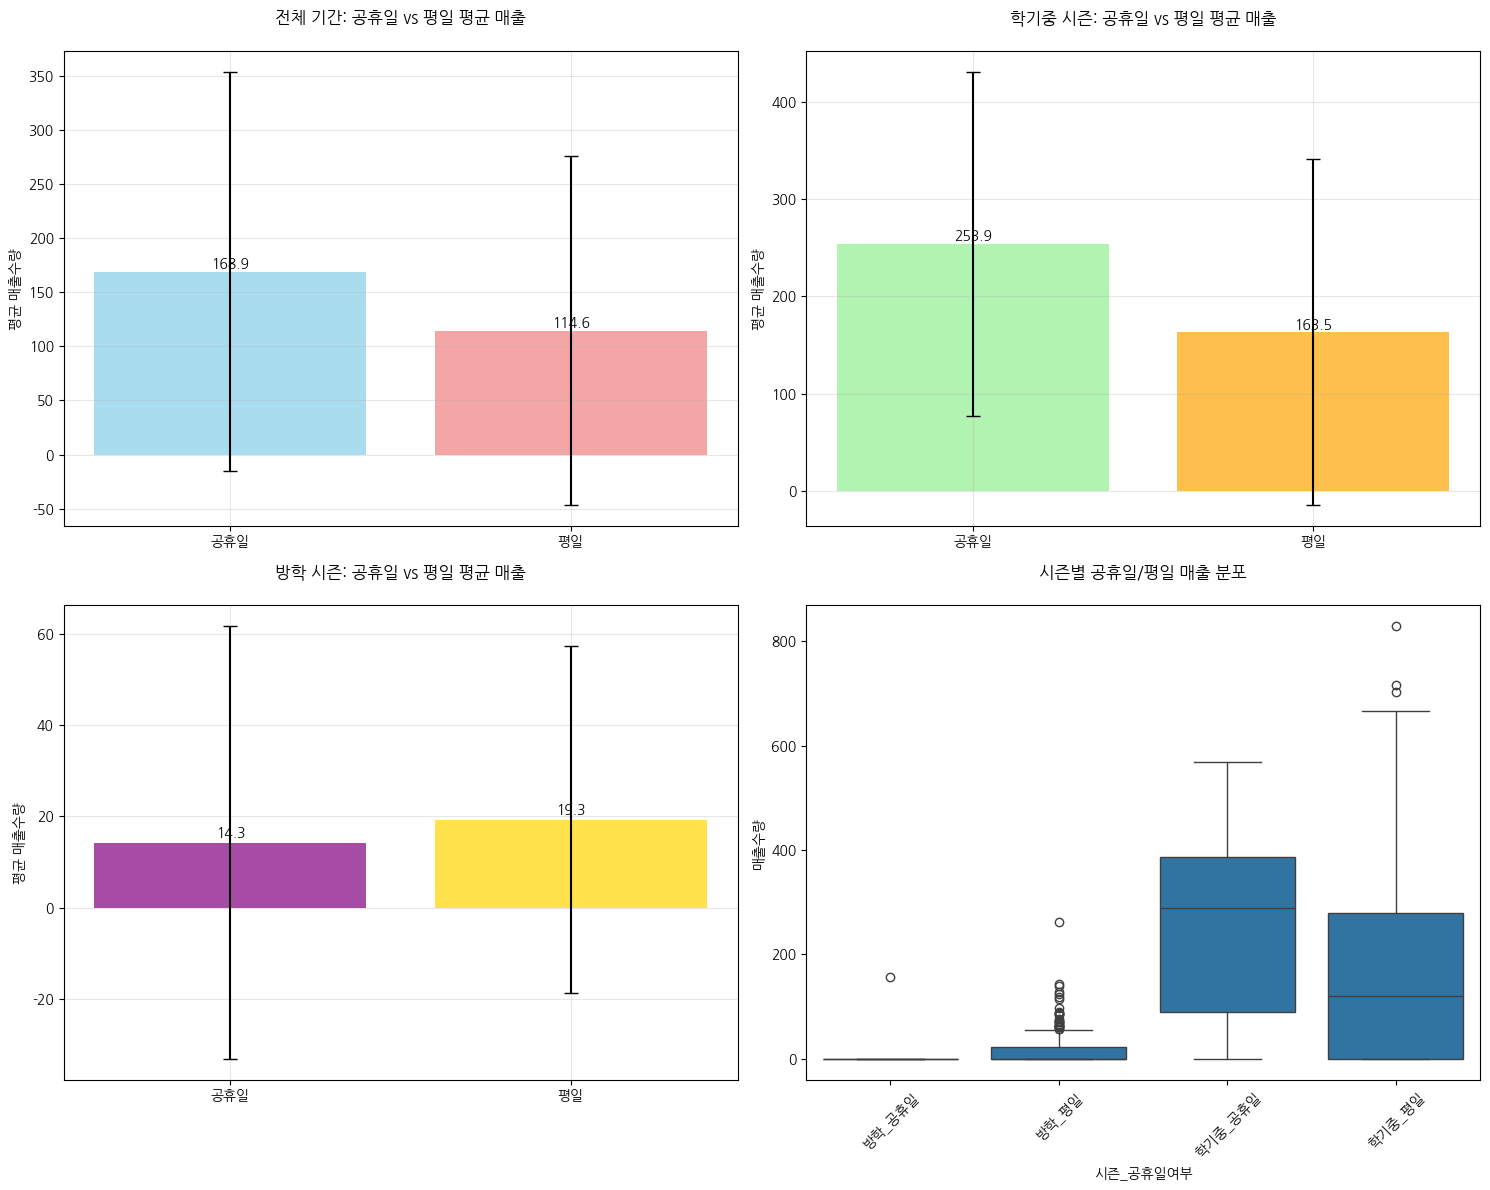


=== 상세 분석 결과 ===

1. 전체 기간 분석:
               count        mean         std  min  25%   50%    75%    max
holiday_label                                                             
공휴일             31.0  168.903226  184.427466  0.0  0.0  92.0  333.0  568.0
평일             501.0  114.566866  161.013844  0.0  0.0  35.0  178.0  828.0

2. 학기중 시즌 분석:
               count       mean         std  min   25%    50%    75%    max
holiday_label                                                              
공휴일             20.0  253.95000  176.265492  0.0  90.5  289.5  386.0  568.0
평일             331.0  163.47432  177.392960  0.0   0.0  120.0  280.0  828.0

3. 방학 시즌 분석:
               count       mean        std  min  25%  50%   75%    max
holiday_label                                                         
공휴일             11.0  14.272727  47.337281  0.0  0.0  0.0   0.0  157.0
평일             170.0  19.341176  38.068936  0.0  0.0  0.0  22.5  262.0

4. 월별 매출 패턴:
holiday_label     공휴일      평일
month  

In [16]:

# 컬럼명 확인 및 정리
print("원본 데이터 컬럼:", df.columns.tolist())
print("데이터 샘플:")
print(df.head())

# 영업일자를 datetime으로 변환
df['영업일자'] = pd.to_datetime(df['영업일자'])

# 느티나무 셀프BBQ 매장 데이터만 필터링
bbq_data = df[df['영업장명_메뉴명'].str.contains(restaurants_name[8], na=False)].copy() # 여기서 restaurants_name[] 숫자 바꿔서 보면 됨

print(f"\n 관련 데이터 수: {len(bbq_data)}")
print("메뉴 목록:")
print(bbq_data['영업장명_메뉴명'].unique())

# 공휴일 목록 정의
holidays_2023 = [
    '2023-01-01', '2023-01-21', '2023-01-22', '2023-01-23', '2023-01-24',
    '2023-03-01', '2023-05-01', '2023-05-05', '2023-05-27', '2023-05-29',
    '2023-06-06', '2023-08-15', '2023-09-28', '2023-09-29', '2023-09-30',
    '2023-10-02', '2023-10-03', '2023-10-09', '2023-12-25'
]

holidays_2024 = [
    '2024-01-01', '2024-02-09', '2024-02-10', '2024-02-11', '2024-02-12',
    '2024-03-01', '2024-04-10', '2024-05-01', '2024-05-05', '2024-05-06',
    '2024-05-15', '2024-06-06', '2024-08-15', '2024-09-16', '2024-09-17',
    '2024-09-18', '2024-10-01', '2024-10-03', '2024-10-09', '2024-12-25'
]

all_holidays = holidays_2023 + holidays_2024
holiday_dates = pd.to_datetime(all_holidays)

# 날짜별로 매출 수량 합계 계산
daily_sales = bbq_data.groupby('영업일자')['매출수량'].sum().reset_index()

# 공휴일 여부 컬럼 추가
daily_sales['is_holiday'] = daily_sales['영업일자'].isin(holiday_dates)

# 월 정보 추가
daily_sales['month'] = daily_sales['영업일자'].dt.month

# 학기/방학 시즌 분류 함수
def classify_season(month):
    if month in [3, 4, 5, 6, 9, 10, 11, 12]:
        return '학기중'
    else:  # 1, 2, 7, 8월
        return '방학'

daily_sales['season'] = daily_sales['month'].apply(classify_season)

# 공휴일/평일 라벨 생성
daily_sales['holiday_label'] = daily_sales['is_holiday'].map({True: '공휴일', False: '평일'})

print(f"\n전체 분석 기간: {daily_sales['영업일자'].min()} ~ {daily_sales['영업일자'].max()}")
print(f"총 영업일 수: {len(daily_sales)}")
print(f"공휴일 수: {daily_sales['is_holiday'].sum()}")
print(f"평일 수: {(~daily_sales['is_holiday']).sum()}")

# 시즌별 데이터 분포 확인
print("\n시즌별 데이터 분포:")
season_distribution = daily_sales.groupby(['season', 'holiday_label']).agg({
    '매출수량': ['count', 'mean', 'std', 'sum']
}).round(2)
print(season_distribution)

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. 전체 기간 공휴일 vs 평일 매출 비교
ax1 = axes[0, 0]
holiday_comparison = daily_sales.groupby('holiday_label')['매출수량'].agg(['mean', 'std']).reset_index()
bars1 = ax1.bar(holiday_comparison['holiday_label'], holiday_comparison['mean'],
                yerr=holiday_comparison['std'], capsize=5, alpha=0.7, color=['skyblue', 'lightcoral'])
ax1.set_title('전체 기간: 공휴일 vs 평일 평균 매출', fontsize=12, pad=20)
ax1.set_ylabel('평균 매출수량')
ax1.grid(True, alpha=0.3)

# 막대 위에 값 표시
for bar, mean_val in zip(bars1, holiday_comparison['mean']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{mean_val:.1f}', ha='center', va='bottom')

# 2. 학기중 시즌 공휴일 vs 평일
ax2 = axes[0, 1]
semester_data = daily_sales[daily_sales['season'] == '학기중']
if len(semester_data) > 0:
    semester_comparison = semester_data.groupby('holiday_label')['매출수량'].agg(['mean', 'std']).reset_index()
    bars2 = ax2.bar(semester_comparison['holiday_label'], semester_comparison['mean'],
                    yerr=semester_comparison['std'], capsize=5, alpha=0.7, color=['lightgreen', 'orange'])
    ax2.set_title('학기중 시즌: 공휴일 vs 평일 평균 매출', fontsize=12, pad=20)
    ax2.set_ylabel('평균 매출수량')
    ax2.grid(True, alpha=0.3)

    for bar, mean_val in zip(bars2, semester_comparison['mean']):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{mean_val:.1f}', ha='center', va='bottom')
else:
    ax2.text(0.5, 0.5, '학기중 데이터 없음', ha='center', va='center', transform=ax2.transAxes)
    ax2.set_title('학기중 시즌: 데이터 없음')

# 3. 방학 시즌 공휴일 vs 평일
ax3 = axes[1, 0]
vacation_data = daily_sales[daily_sales['season'] == '방학']
if len(vacation_data) > 0:
    vacation_comparison = vacation_data.groupby('holiday_label')['매출수량'].agg(['mean', 'std']).reset_index()
    bars3 = ax3.bar(vacation_comparison['holiday_label'], vacation_comparison['mean'],
                    yerr=vacation_comparison['std'], capsize=5, alpha=0.7, color=['purple', 'gold'])
    ax3.set_title('방학 시즌: 공휴일 vs 평일 평균 매출', fontsize=12, pad=20)
    ax3.set_ylabel('평균 매출수량')
    ax3.grid(True, alpha=0.3)

    for bar, mean_val in zip(bars3, vacation_comparison['mean']):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{mean_val:.1f}', ha='center', va='bottom')
else:
    ax3.text(0.5, 0.5, '방학 데이터 없음', ha='center', va='center', transform=ax3.transAxes)
    ax3.set_title('방학 시즌: 데이터 없음')

# 4. 박스플롯으로 분포 비교
ax4 = axes[1, 1]
if len(daily_sales) > 0:
    # 시즌과 공휴일 조합 생성
    daily_sales['season_holiday'] = daily_sales['season'] + '_' + daily_sales['holiday_label']

    # 각 조합별로 데이터가 있는지 확인
    combinations = daily_sales['season_holiday'].unique()
    valid_combinations = []
    for combo in combinations:
        if len(daily_sales[daily_sales['season_holiday'] == combo]) > 0:
            valid_combinations.append(combo)

    if valid_combinations:
        box_data = daily_sales[daily_sales['season_holiday'].isin(valid_combinations)]
        sns.boxplot(data=box_data, x='season_holiday', y='매출수량', ax=ax4)
        ax4.set_title('시즌별 공휴일/평일 매출 분포', fontsize=12, pad=20)
        ax4.set_xlabel('시즌_공휴일여부')
        ax4.set_ylabel('매출수량')
        ax4.tick_params(axis='x', rotation=45)
    else:
        ax4.text(0.5, 0.5, '분석 가능한 데이터 없음', ha='center', va='center', transform=ax4.transAxes)

plt.tight_layout()
plt.show()

# 통계적 분석 결과 출력
print("\n=== 상세 분석 결과 ===")

# 전체 통계
print("\n1. 전체 기간 분석:")
overall_stats = daily_sales.groupby('holiday_label')['매출수량'].describe()
print(overall_stats)

# 학기중 통계
print("\n2. 학기중 시즌 분석:")
if len(daily_sales[daily_sales['season'] == '학기중']) > 0:
    semester_stats = daily_sales[daily_sales['season'] == '학기중'].groupby('holiday_label')['매출수량'].describe()
    print(semester_stats)
else:
    print("학기중 데이터가 충분하지 않습니다.")

# 방학 통계
print("\n3. 방학 시즌 분석:")
if len(daily_sales[daily_sales['season'] == '방학']) > 0:
    vacation_stats = daily_sales[daily_sales['season'] == '방학'].groupby('holiday_label')['매출수량'].describe()
    print(vacation_stats)
else:
    print("방학 데이터가 충분하지 않습니다.")

# 월별 매출 패턴
print("\n4. 월별 매출 패턴:")
monthly_pattern = daily_sales.groupby(['month', 'holiday_label'])['매출수량'].mean().unstack(fill_value=0)
print(monthly_pattern.round(2))

# 결론 도출
print("\n=== 분석 결론 ===")
total_holiday_mean = daily_sales[daily_sales['is_holiday']]['매출수량'].mean()
total_weekday_mean = daily_sales[~daily_sales['is_holiday']]['매출수량'].mean()

print(f"전체 기간 평균 매출:")
print(f"- 공휴일: {total_holiday_mean:.2f}")
print(f"- 평일: {total_weekday_mean:.2f}")
print(f"- 차이: {total_holiday_mean - total_weekday_mean:.2f} ({'공휴일이 높음' if total_holiday_mean > total_weekday_mean else '평일이 높음'})")

# 시즌별 비교
for season in ['학기중', '방학']:
    season_data = daily_sales[daily_sales['season'] == season]
    if len(season_data) > 0:
        holiday_mean = season_data[season_data['is_holiday']]['매출수량'].mean()
        weekday_mean = season_data[~season_data['is_holiday']]['매출수량'].mean()

        print(f"\n{season} 시즌 평균 매출:")
        print(f"- 공휴일: {holiday_mean:.2f}")
        print(f"- 평일: {weekday_mean:.2f}")
        print(f"- 차이: {holiday_mean - weekday_mean:.2f} ({'공휴일이 높음' if holiday_mean > weekday_mean else '평일이 높음'})")

## 공휴일에 주말 포함

원본 데이터 컬럼: ['영업일자', '영업장명_메뉴명', '매출수량']
데이터 샘플:
        영업일자            영업장명_메뉴명  매출수량
0 2023-01-01  느티나무 셀프BBQ_1인 수저세트     0
1 2023-01-02  느티나무 셀프BBQ_1인 수저세트     0
2 2023-01-03  느티나무 셀프BBQ_1인 수저세트     0
3 2023-01-04  느티나무 셀프BBQ_1인 수저세트     0
4 2023-01-05  느티나무 셀프BBQ_1인 수저세트     0

 관련 데이터 수: 6384
메뉴 목록:
['포레스트릿_꼬치어묵' '포레스트릿_떡볶이' '포레스트릿_복숭아 아이스티' '포레스트릿_생수' '포레스트릿_스프라이트'
 '포레스트릿_아메리카노(HOT)' '포레스트릿_아메리카노(ICE)' '포레스트릿_치즈 핫도그' '포레스트릿_카페라떼(HOT)'
 '포레스트릿_카페라떼(ICE)' '포레스트릿_코카콜라' '포레스트릿_페스츄리 소시지']

전체 분석 기간: 2023-01-01 00:00:00 ~ 2024-06-15 00:00:00
총 영업일 수: 532
공휴일 수: 175
평일 수: 357

시즌별 데이터 분포:
                      매출수량                          
                     count     mean      std     sum
season holiday_label                                
방학     공휴일(주말포함)        57  2066.02  1706.56  117763
       평일              124  1051.06   913.96  130331
학기중    공휴일(주말포함)       118   308.00   617.31   36344
       평일              233    90.06   337.39   20983


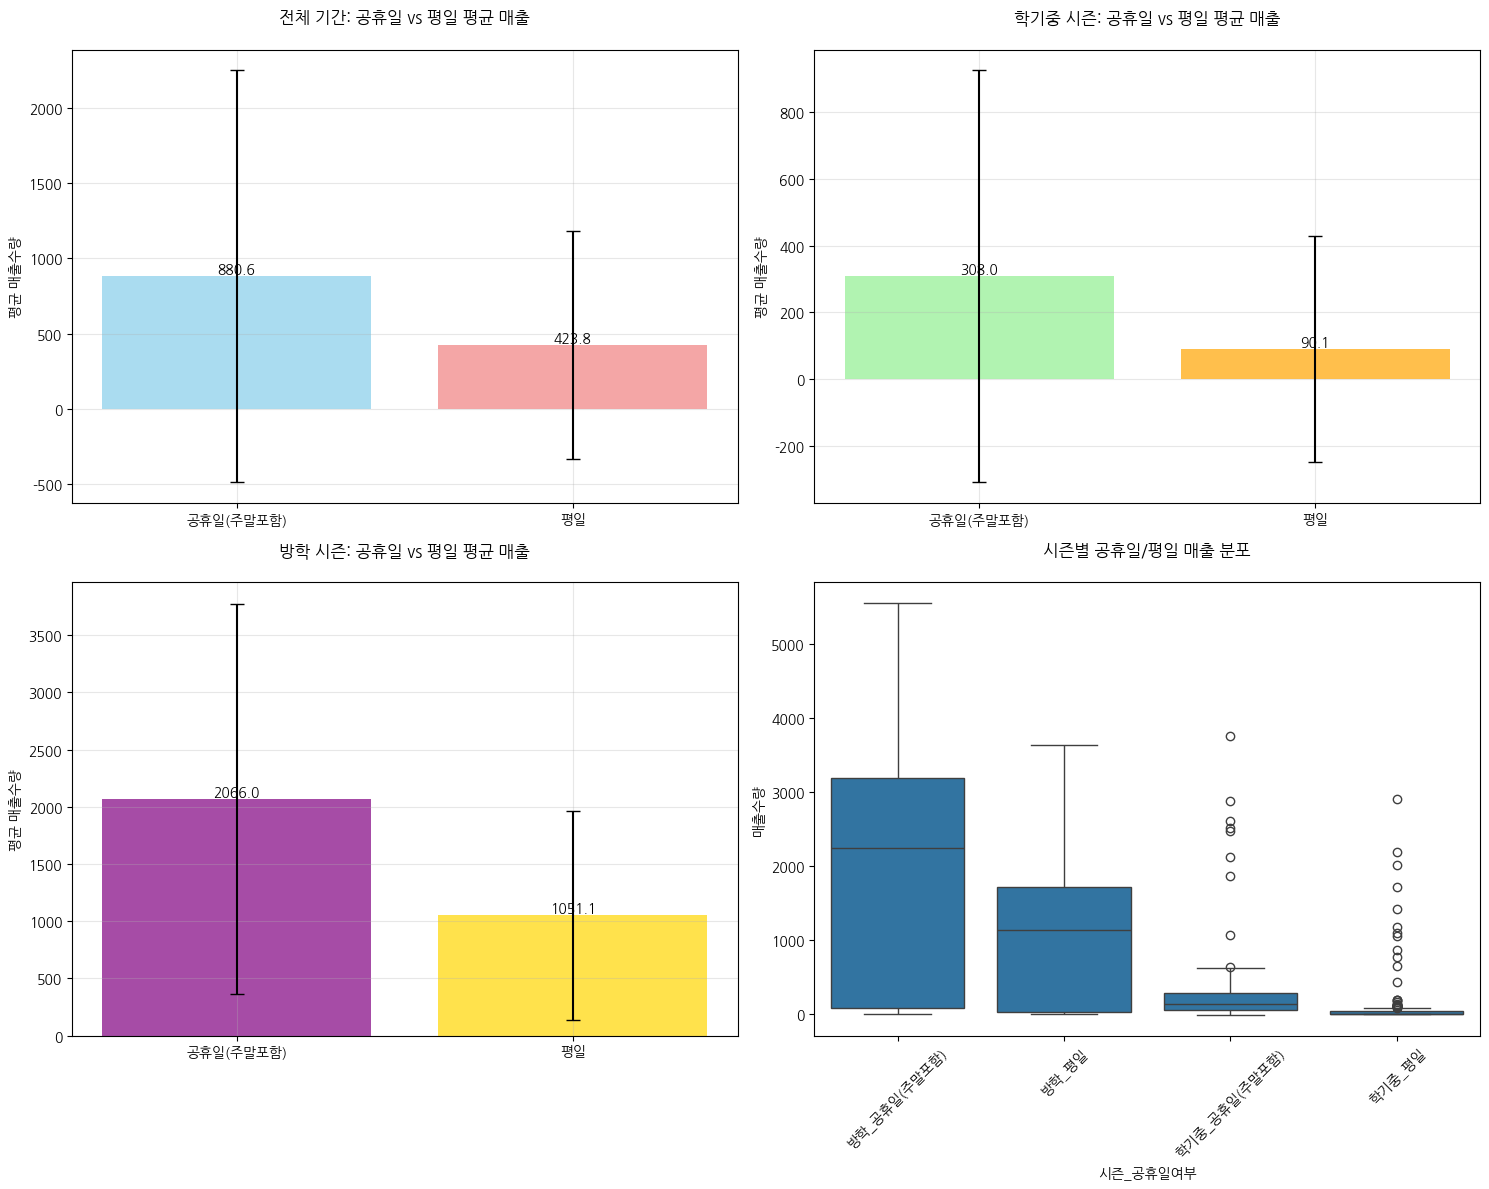

In [53]:

# 컬럼명 확인 및 정리
print("원본 데이터 컬럼:", df.columns.tolist())
print("데이터 샘플:")
print(df.head())

# 영업일자를 datetime으로 변환
df['영업일자'] = pd.to_datetime(df['영업일자'])

# 느티나무 셀프BBQ 매장 데이터만 필터링
bbq_data = df[df['영업장명_메뉴명'].str.contains(restaurants_name[6], na=False)].copy() # 여기서 restaurants_name[] 숫자 바꿔서 보면 됨

print(f"\n 관련 데이터 수: {len(bbq_data)}")
print("메뉴 목록:")
print(bbq_data['영업장명_메뉴명'].unique())

# 공휴일 목록 정의
holidays_2023 = [
    '2023-01-01', '2023-01-21', '2023-01-22', '2023-01-23', '2023-01-24',
    '2023-03-01', '2023-05-01', '2023-05-05', '2023-05-27', '2023-05-29',
    '2023-06-06', '2023-08-15', '2023-09-28', '2023-09-29', '2023-09-30',
    '2023-10-02', '2023-10-03', '2023-10-09', '2023-12-25'
]

holidays_2024 = [
    '2024-01-01', '2024-02-09', '2024-02-10', '2024-02-11', '2024-02-12',
    '2024-03-01', '2024-04-10', '2024-05-01', '2024-05-05', '2024-05-06',
    '2024-05-15', '2024-06-06', '2024-08-15', '2024-09-16', '2024-09-17',
    '2024-09-18', '2024-10-01', '2024-10-03', '2024-10-09', '2024-12-25'
]

all_holidays = holidays_2023 + holidays_2024
holiday_dates = pd.to_datetime(all_holidays)

# 날짜별로 매출 수량 합계 계산
daily_sales = bbq_data.groupby('영업일자')['매출수량'].sum().reset_index()

# 공휴일 여부 컬럼 추가 (기존 공휴일 + 주말)
daily_sales['is_weekend'] = daily_sales['영업일자'].dt.weekday >= 5  # 토요일(5), 일요일(6)
daily_sales['is_official_holiday'] = daily_sales['영업일자'].isin(holiday_dates)
daily_sales['is_holiday'] = daily_sales['is_weekend'] | daily_sales['is_official_holiday']  # 주말 또는 공휴일

# 월 정보 추가
daily_sales['month'] = daily_sales['영업일자'].dt.month

# 학기/방학 시즌 분류 함수
def classify_season(month):
    if month in [3, 4, 5, 6, 9, 10, 11, 12]:
        return '학기중'
    else:  # 1, 2, 7, 8월
        return '방학'

daily_sales['season'] = daily_sales['month'].apply(classify_season)

# 공휴일/평일 라벨 생성 (주말 포함)
daily_sales['holiday_label'] = daily_sales['is_holiday'].map({True: '공휴일(주말포함)', False: '평일'})

print(f"\n전체 분석 기간: {daily_sales['영업일자'].min()} ~ {daily_sales['영업일자'].max()}")
print(f"총 영업일 수: {len(daily_sales)}")
print(f"공휴일 수: {daily_sales['is_holiday'].sum()}")
print(f"평일 수: {(~daily_sales['is_holiday']).sum()}")

# 시즌별 데이터 분포 확인
print("\n시즌별 데이터 분포:")
season_distribution = daily_sales.groupby(['season', 'holiday_label']).agg({
    '매출수량': ['count', 'mean', 'std', 'sum']
}).round(2)
print(season_distribution)

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. 전체 기간 공휴일 vs 평일 매출 비교
ax1 = axes[0, 0]
holiday_comparison = daily_sales.groupby('holiday_label')['매출수량'].agg(['mean', 'std']).reset_index()
bars1 = ax1.bar(holiday_comparison['holiday_label'], holiday_comparison['mean'],
                yerr=holiday_comparison['std'], capsize=5, alpha=0.7, color=['skyblue', 'lightcoral'])
ax1.set_title('전체 기간: 공휴일 vs 평일 평균 매출', fontsize=12, pad=20)
ax1.set_ylabel('평균 매출수량')
ax1.grid(True, alpha=0.3)

# 막대 위에 값 표시
for bar, mean_val in zip(bars1, holiday_comparison['mean']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{mean_val:.1f}', ha='center', va='bottom')

# 2. 학기중 시즌 공휴일 vs 평일
ax2 = axes[0, 1]
semester_data = daily_sales[daily_sales['season'] == '학기중']
if len(semester_data) > 0:
    semester_comparison = semester_data.groupby('holiday_label')['매출수량'].agg(['mean', 'std']).reset_index()
    bars2 = ax2.bar(semester_comparison['holiday_label'], semester_comparison['mean'],
                    yerr=semester_comparison['std'], capsize=5, alpha=0.7, color=['lightgreen', 'orange'])
    ax2.set_title('학기중 시즌: 공휴일 vs 평일 평균 매출', fontsize=12, pad=20)
    ax2.set_ylabel('평균 매출수량')
    ax2.grid(True, alpha=0.3)

    for bar, mean_val in zip(bars2, semester_comparison['mean']):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{mean_val:.1f}', ha='center', va='bottom')
else:
    ax2.text(0.5, 0.5, '학기중 데이터 없음', ha='center', va='center', transform=ax2.transAxes)
    ax2.set_title('학기중 시즌: 데이터 없음')

# 3. 방학 시즌 공휴일 vs 평일
ax3 = axes[1, 0]
vacation_data = daily_sales[daily_sales['season'] == '방학']
if len(vacation_data) > 0:
    vacation_comparison = vacation_data.groupby('holiday_label')['매출수량'].agg(['mean', 'std']).reset_index()
    bars3 = ax3.bar(vacation_comparison['holiday_label'], vacation_comparison['mean'],
                    yerr=vacation_comparison['std'], capsize=5, alpha=0.7, color=['purple', 'gold'])
    ax3.set_title('방학 시즌: 공휴일 vs 평일 평균 매출', fontsize=12, pad=20)
    ax3.set_ylabel('평균 매출수량')
    ax3.grid(True, alpha=0.3)

    for bar, mean_val in zip(bars3, vacation_comparison['mean']):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{mean_val:.1f}', ha='center', va='bottom')
else:
    ax3.text(0.5, 0.5, '방학 데이터 없음', ha='center', va='center', transform=ax3.transAxes)
    ax3.set_title('방학 시즌: 데이터 없음')

# 4. 박스플롯으로 분포 비교
ax4 = axes[1, 1]
if len(daily_sales) > 0:
    # 시즌과 공휴일 조합 생성
    daily_sales['season_holiday'] = daily_sales['season'] + '_' + daily_sales['holiday_label']

    # 각 조합별로 데이터가 있는지 확인
    combinations = daily_sales['season_holiday'].unique()
    valid_combinations = []
    for combo in combinations:
        if len(daily_sales[daily_sales['season_holiday'] == combo]) > 0:
            valid_combinations.append(combo)

    if valid_combinations:
        box_data = daily_sales[daily_sales['season_holiday'].isin(valid_combinations)]
        sns.boxplot(data=box_data, x='season_holiday', y='매출수량', ax=ax4)
        ax4.set_title('시즌별 공휴일/평일 매출 분포', fontsize=12, pad=20)
        ax4.set_xlabel('시즌_공휴일여부')
        ax4.set_ylabel('매출수량')
        ax4.tick_params(axis='x', rotation=45)
    else:
        ax4.text(0.5, 0.5, '분석 가능한 데이터 없음', ha='center', va='center', transform=ax4.transAxes)

plt.tight_layout()
plt.show()

# 통계적 분석 결과 출력
# print("\n=== 상세 분석 결과 ===")

# # 전체 통계
# print("\n1. 전체 기간 분석:")
# overall_stats = daily_sales.groupby('holiday_label')['매출수량'].describe()
# print(overall_stats)

# # 학기중 통계
# print("\n2. 학기중 시즌 분석:")
# if len(daily_sales[daily_sales['season'] == '학기중']) > 0:
#     semester_stats = daily_sales[daily_sales['season'] == '학기중'].groupby('holiday_label')['매출수량'].describe()
#     print(semester_stats)
# else:
#     print("학기중 데이터가 충분하지 않습니다.")

# # 방학 통계
# print("\n3. 방학 시즌 분석:")
# if len(daily_sales[daily_sales['season'] == '방학']) > 0:
#     vacation_stats = daily_sales[daily_sales['season'] == '방학'].groupby('holiday_label')['매출수량'].describe()
#     print(vacation_stats)
# else:
#     print("방학 데이터가 충분하지 않습니다.")

# # 월별 매출 패턴
# print("\n4. 월별 매출 패턴:")
# monthly_pattern = daily_sales.groupby(['month', 'holiday_label'])['매출수량'].mean().unstack(fill_value=0)
# print(monthly_pattern.round(2))

# # 결론 도출
# print("\n=== 분석 결론 ===")
# total_holiday_mean = daily_sales[daily_sales['is_holiday']]['매출수량'].mean()
# total_weekday_mean = daily_sales[~daily_sales['is_holiday']]['매출수량'].mean()

# print(f"전체 기간 평균 매출:")
# print(f"- 공휴일: {total_holiday_mean:.2f}")
# print(f"- 평일: {total_weekday_mean:.2f}")
# print(f"- 차이: {total_holiday_mean - total_weekday_mean:.2f} ({'공휴일이 높음' if total_holiday_mean > total_weekday_mean else '평일이 높음'})")

# # 시즌별 비교
# for season in ['학기중', '방학']:
#     season_data = daily_sales[daily_sales['season'] == season]
#     if len(season_data) > 0:
#         holiday_mean = season_data[season_data['is_holiday']]['매출수량'].mean()
#         weekday_mean = season_data[~season_data['is_holiday']]['매출수량'].mean()

#         print(f"\n{season} 시즌 평균 매출:")
#         print(f"- 공휴일: {holiday_mean:.2f}")
#         print(f"- 평일: {weekday_mean:.2f}")
#         print(f"- 차이: {holiday_mean - weekday_mean:.2f} ({'공휴일이 높음' if holiday_mean > weekday_mean else '평일이 높음'})")

# 매장별, 요일별 일 매출 평균 시각화

데이터 기본 정보:
전체 데이터 수: 102,676건
분석 기간: 2023-01-01 00:00:00 ~ 2024-06-15 00:00:00
매장 수: 9개
공휴일 수: 5983건

매장 목록:
 1. 느티나무 셀프BBQ
 2. 담하
 3. 라그로타
 4. 미라시아
 5. 연회장
 6. 카페테리아
 7. 포레스트릿
 8. 화담숲주막
 9. 화담숲카페

매장별 요일별 평균 매출 요약:
요일            월요일    화요일    수요일    목요일    금요일    토요일    일요일     공휴일
매장명                                                                
느티나무 셀프BBQ  109.8   75.7  136.2  276.4  206.7   93.6   48.8    50.8
담하          149.5  188.9  165.3  201.1  295.5  345.4  243.5   349.6
라그로타          5.0   26.6   27.1   31.6   38.5   53.6   38.0    49.9
미라시아        152.5  153.6  130.4  157.6  199.6  213.1  236.7   289.9
연회장          32.8   62.7   44.9   97.0   80.7   47.9   16.5    25.7
카페테리아       331.2  403.4  405.1  400.4  504.5  568.1  455.3   671.0
포레스트릿       334.5  381.7  367.6  429.5  599.6  979.5  703.4  1062.4
화담숲주막        74.5  221.8  183.3  209.6  277.3  435.1  442.2   435.7
화담숲카페        25.5  102.4   79.7   99.2  131.1  189.7  168.7   168.9

전체 매장 요일별 평균 (공휴일 포함):
월요일: 135.0
화

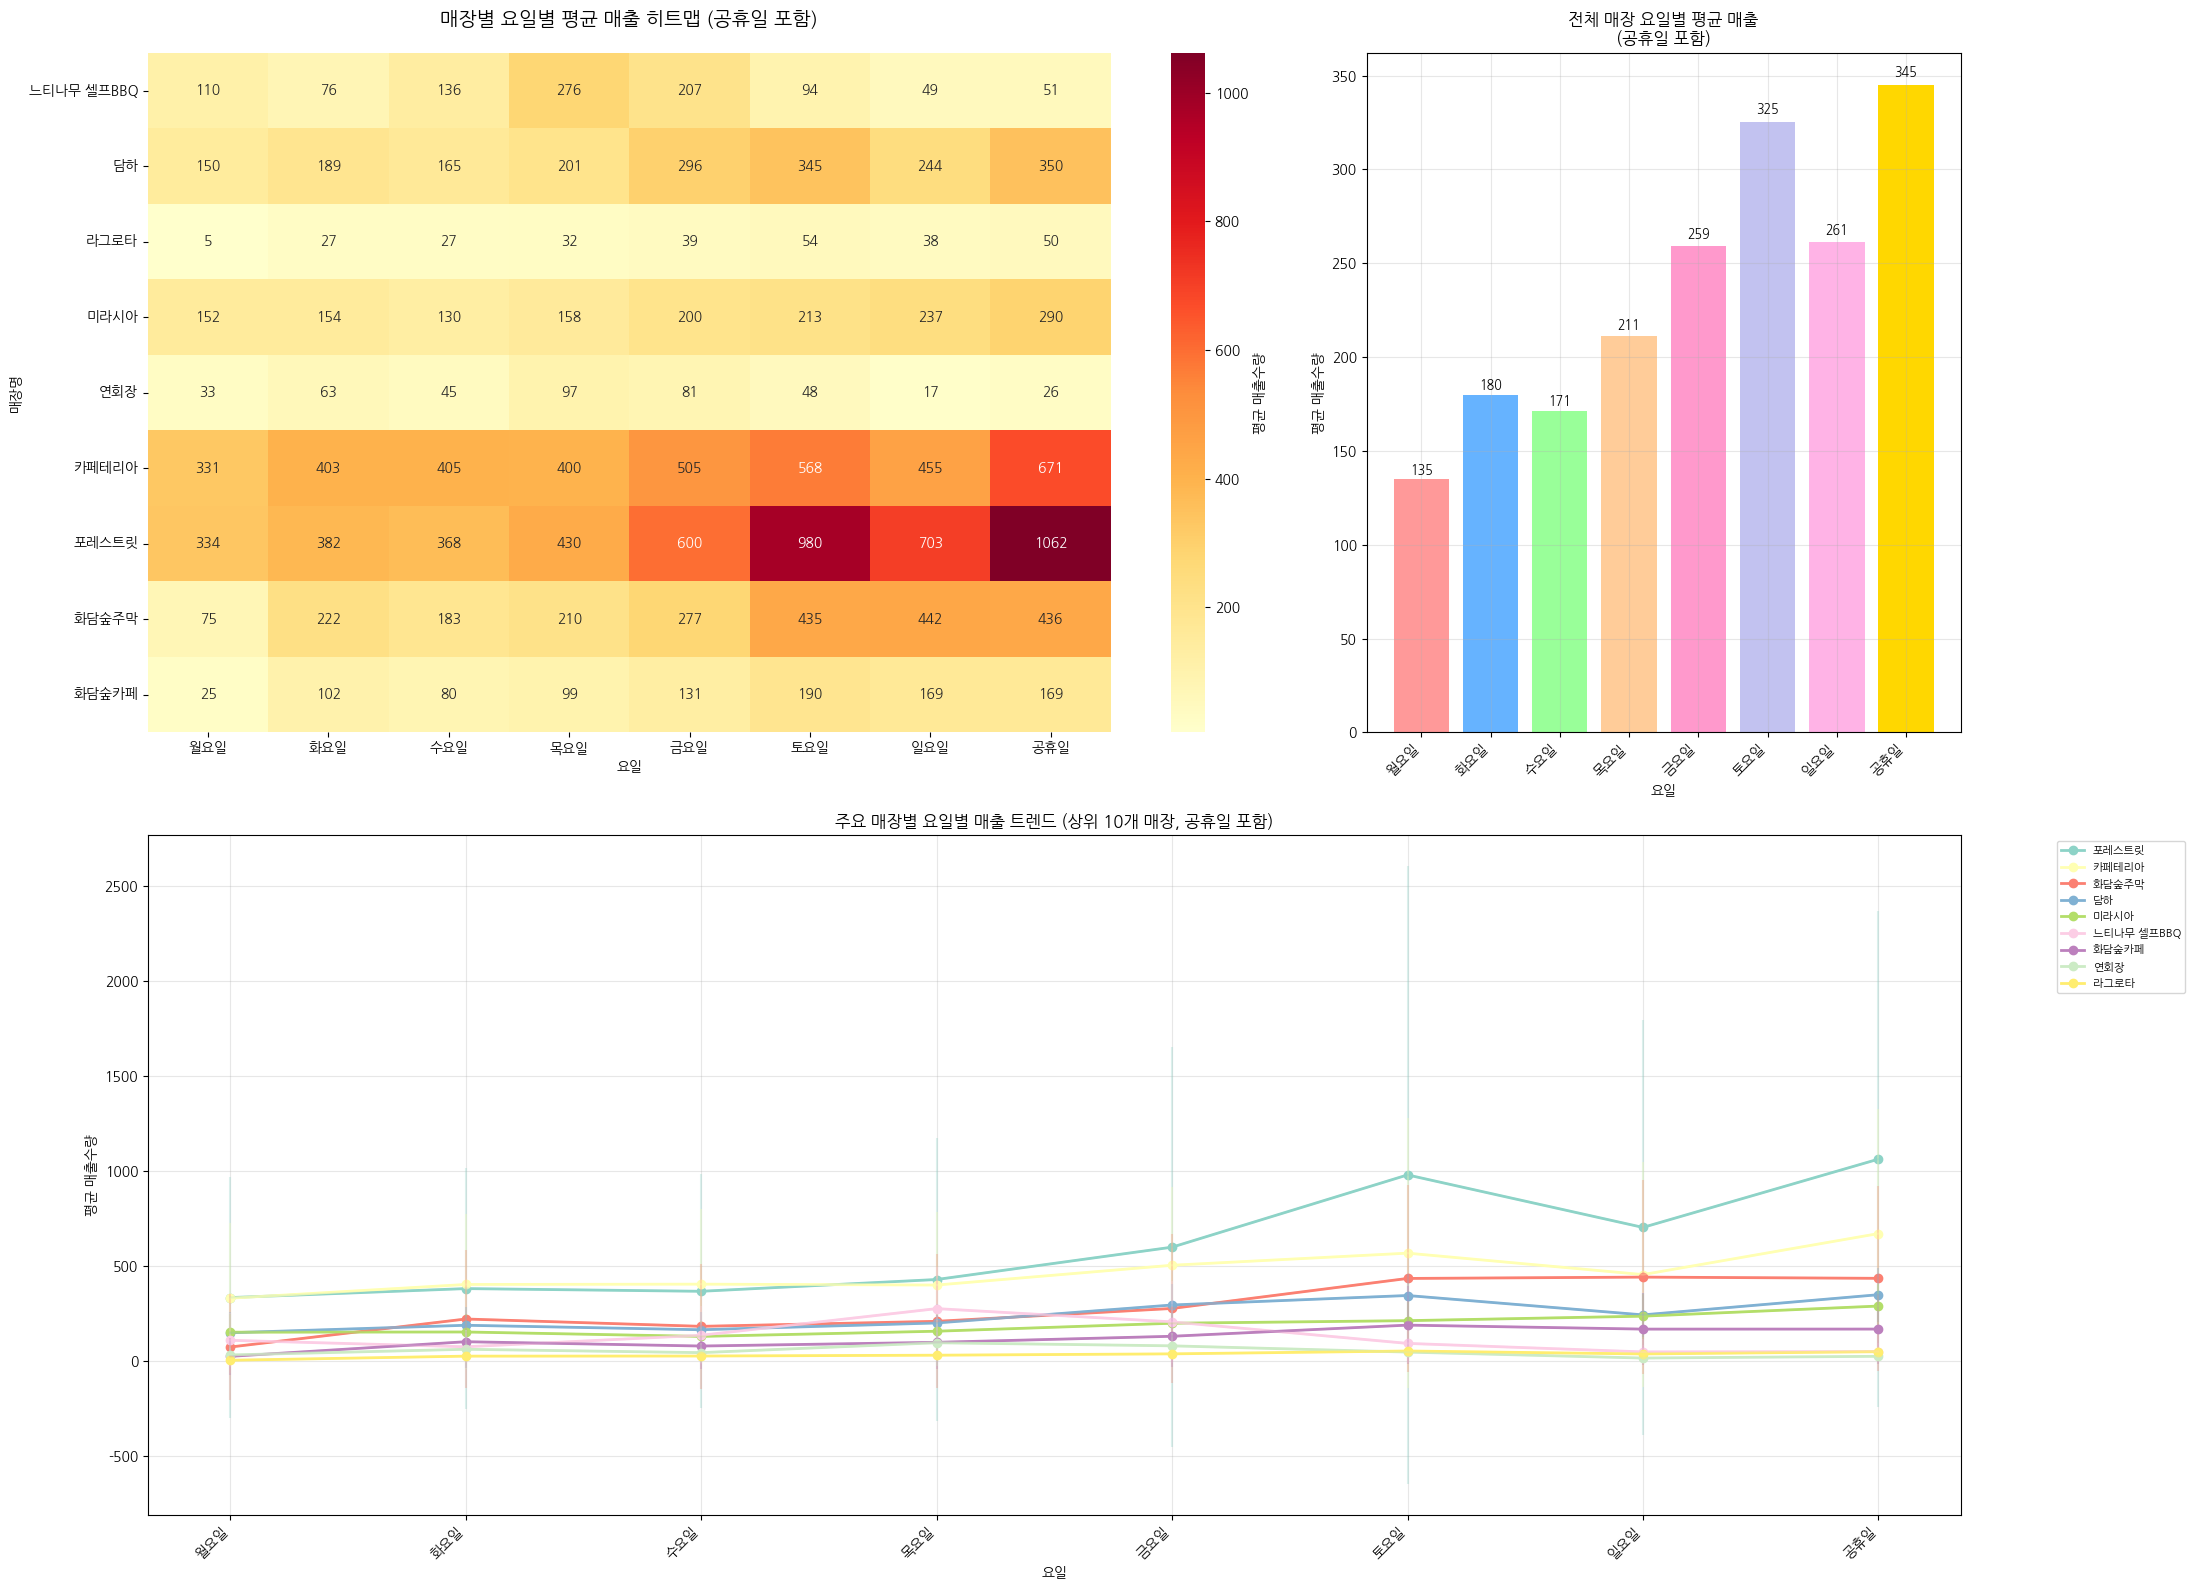


=== 매장별 요일 패턴 분석 ===

느티나무 셀프BBQ:
  최고 매출 요일: 목요일 (276.4)
  최저 매출 요일: 일요일 (48.8)
  요일간 편차: 227.6 (466.0% 차이)

담하:
  최고 매출 요일: 공휴일 (349.6)
  최저 매출 요일: 월요일 (149.5)
  요일간 편차: 200.1 (133.9% 차이)

라그로타:
  최고 매출 요일: 토요일 (53.6)
  최저 매출 요일: 월요일 (5.0)
  요일간 편차: 48.6 (981.6% 차이)

미라시아:
  최고 매출 요일: 공휴일 (289.9)
  최저 매출 요일: 수요일 (130.4)
  요일간 편차: 159.6 (122.4% 차이)

연회장:
  최고 매출 요일: 목요일 (97.0)
  최저 매출 요일: 일요일 (16.5)
  요일간 편차: 80.5 (486.9% 차이)

카페테리아:
  최고 매출 요일: 공휴일 (671.0)
  최저 매출 요일: 월요일 (331.2)
  요일간 편차: 339.8 (102.6% 차이)

포레스트릿:
  최고 매출 요일: 공휴일 (1062.4)
  최저 매출 요일: 월요일 (334.5)
  요일간 편차: 727.9 (217.6% 차이)

화담숲주막:
  최고 매출 요일: 일요일 (442.2)
  최저 매출 요일: 월요일 (74.5)
  요일간 편차: 367.7 (493.5% 차이)

화담숲카페:
  최고 매출 요일: 토요일 (189.7)
  최저 매출 요일: 월요일 (25.5)
  요일간 편차: 164.2 (645.0% 차이)

=== 요일별 매장 매출 순위 (상위 5개) ===

월요일:
  1. 포레스트릿: 334.5
  2. 카페테리아: 331.2
  3. 미라시아: 152.5
  4. 담하: 149.5
  5. 느티나무 셀프BBQ: 109.8

화요일:
  1. 카페테리아: 403.4
  2. 포레스트릿: 381.7
  3. 화담숲주막: 221.8
  4. 담하: 188.9
  5. 미라시아: 153.6

수요일:
  1. 카페테

In [18]:


# 영업일자를 datetime으로 변환
df['영업일자'] = pd.to_datetime(df['영업일자'])

# 매장명과 메뉴명 분리
df['매장명'] = df['영업장명_메뉴명'].str.split('_').str[0]

# 요일 정보 추가 (0=월요일, 6=일요일)
df['요일번호'] = df['영업일자'].dt.dayofweek
df['요일명'] = df['영업일자'].dt.day_name()

# 공휴일 목록 정의
# holidays_2023 = [
#     '2023-01-01', '2023-01-21', '2023-01-22', '2023-01-23', '2023-01-24',
#     '2023-03-01', '2023-05-01', '2023-05-05', '2023-05-27', '2023-05-29',
#     '2023-06-06', '2023-08-15', '2023-09-28', '2023-09-29', '2023-09-30',
#     '2023-10-02', '2023-10-03', '2023-10-09', '2023-12-25'
# ]

# holidays_2024 = [
#     '2024-01-01', '2024-02-09', '2024-02-10', '2024-02-11', '2024-02-12',
#     '2024-03-01', '2024-04-10', '2024-05-01', '2024-05-05', '2024-05-06',
#     '2024-05-15', '2024-06-06', '2024-08-15', '2024-09-16', '2024-09-17',
#     '2024-09-18', '2024-10-01', '2024-10-03', '2024-10-09', '2024-12-25'
# ]

all_holidays = holidays_2023 + holidays_2024
holiday_dates = pd.to_datetime(all_holidays)

# 한글 요일명 매핑
weekday_mapping = {
    'Monday': '월요일',
    'Tuesday': '화요일',
    'Wednesday': '수요일',
    'Thursday': '목요일',
    'Friday': '금요일',
    'Saturday': '토요일',
    'Sunday': '일요일'
}
df['요일'] = df['요일명'].map(weekday_mapping)

# 공휴일 여부 확인 및 요일 재분류
df['is_holiday'] = df['영업일자'].isin(holiday_dates)
df['요일_공휴일포함'] = df.apply(lambda row: '공휴일' if row['is_holiday'] else row['요일'], axis=1)

# 요일 순서 정의 (월요일부터 시작, 공휴일 추가)
weekday_order = ['월요일', '화요일', '수요일', '목요일', '금요일', '토요일', '일요일', '공휴일']

print("데이터 기본 정보:")
print(f"전체 데이터 수: {len(df):,}건")
print(f"분석 기간: {df['영업일자'].min()} ~ {df['영업일자'].max()}")
print(f"매장 수: {df['매장명'].nunique()}개")
print(f"공휴일 수: {df['is_holiday'].sum()}건")
print("\n매장 목록:")
for i, store in enumerate(df['매장명'].unique(), 1):
    print(f"{i:2d}. {store}")

# 일별 매장별 매출 합계 계산 (공휴일 포함)
daily_store_sales = df.groupby(['영업일자', '매장명', '요일_공휴일포함'])['매출수량'].sum().reset_index()

# 매장별 요일별 평균 매출 계산 (공휴일 포함)
store_weekday_avg = daily_store_sales.groupby(['매장명', '요일_공휴일포함'])['매출수량'].agg(['mean', 'std', 'count']).reset_index()
store_weekday_avg.columns = ['매장명', '요일', '평균매출', '표준편차', '데이터수']
store_weekday_avg['표준편차'] = store_weekday_avg['표준편차'].fillna(0)

# 피벗 테이블 생성 (히트맵용)
heatmap_data = store_weekday_avg.pivot(index='매장명', columns='요일', values='평균매출')
heatmap_data = heatmap_data.reindex(columns=weekday_order)

print(f"\n매장별 요일별 평균 매출 요약:")
print(heatmap_data.round(1))

# 전체 평균 계산 (공휴일 포함)
overall_avg = daily_store_sales.groupby('요일_공휴일포함')['매출수량'].mean()
overall_avg = overall_avg.reindex(weekday_order)

print(f"\n전체 매장 요일별 평균 (공휴일 포함):")
for day, avg in overall_avg.items():
    if pd.notna(avg):
        print(f"{day}: {avg:.1f}")

# 시각화
fig = plt.figure(figsize=(22, 16))

# 1. 히트맵 (매장별 요일별 평균 매출)
ax1 = plt.subplot(2, 3, (1, 2))
mask = heatmap_data.isnull()
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd',
            mask=mask, ax=ax1, cbar_kws={'label': '평균 매출수량'})
ax1.set_title('매장별 요일별 평균 매출 히트맵 (공휴일 포함)', fontsize=14, pad=20)
ax1.set_xlabel('요일')
ax1.set_ylabel('매장명')

# 2. 전체 평균 요일별 트렌드 (공휴일 포함)
ax2 = plt.subplot(2, 3, 3)
valid_days = overall_avg.dropna()
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#ff99cc', '#c2c2f0', '#ffb3e6', '#ffd700']
day_colors = colors[:len(valid_days)]

bars = ax2.bar(range(len(valid_days)), valid_days.values, color=day_colors)
ax2.set_title('전체 매장 요일별 평균 매출\n(공휴일 포함)', fontsize=12)
ax2.set_xlabel('요일')
ax2.set_ylabel('평균 매출수량')
ax2.set_xticks(range(len(valid_days)))
ax2.set_xticklabels(valid_days.index, rotation=45, ha='right')
ax2.grid(True, alpha=0.3)

# 막대 위에 값 표시
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
             f'{height:.0f}', ha='center', va='bottom', fontsize=9)

# 3. 매장별 라인플롯 (상위 5개 매장) - 공휴일 포함
ax3 = plt.subplot(2, 3, (4, 6))

# 매장별 총 매출로 정렬하여 상위 매장 선택
store_total_sales = daily_store_sales.groupby('매장명')['매출수량'].sum().sort_values(ascending=False)
top_stores = store_total_sales.head(10).index

colors = plt.cm.Set3(np.linspace(0, 1, len(top_stores)))

for i, store in enumerate(top_stores):
    store_data = store_weekday_avg[store_weekday_avg['매장명'] == store]
    store_data = store_data.set_index('요일').reindex(weekday_order)

    if not store_data['평균매출'].isna().all():
        # NaN 값이 아닌 데이터만 플롯
        valid_data = store_data['평균매출'].dropna()
        valid_indices = [weekday_order.index(day) for day in valid_data.index]

        ax3.plot(valid_indices, valid_data.values,
                marker='o', linewidth=2, label=store, color=colors[i], markersize=6)

        # 에러바 추가 (표준편차) - 유효한 데이터만
        valid_std = store_data.loc[valid_data.index, '표준편차']
        ax3.errorbar(valid_indices, valid_data.values,
                    yerr=valid_std.values, alpha=0.3, color=colors[i])

ax3.set_title('주요 매장별 요일별 매출 트렌드 (상위 10개 매장, 공휴일 포함)', fontsize=12)
ax3.set_xlabel('요일')
ax3.set_ylabel('평균 매출수량')
ax3.set_xticks(range(len(weekday_order)))
ax3.set_xticklabels(weekday_order, rotation=45, ha='right')
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 상세 통계 출력
print("\n=== 매장별 요일 패턴 분석 ===")

# 각 매장의 최고/최저 요일 찾기
for store in heatmap_data.index:
    store_data = heatmap_data.loc[store].dropna()
    if len(store_data) > 0:
        max_day = store_data.idxmax()
        min_day = store_data.idxmin()
        max_val = store_data.max()
        min_val = store_data.min()

        print(f"\n{store}:")
        print(f"  최고 매출 요일: {max_day} ({max_val:.1f})")
        print(f"  최저 매출 요일: {min_day} ({min_val:.1f})")
        print(f"  요일간 편차: {max_val - min_val:.1f} ({((max_val/min_val - 1) * 100):.1f}% 차이)")

# 요일별 매장 순위
print(f"\n=== 요일별 매장 매출 순위 (상위 5개) ===")
for day in weekday_order:
    day_data = heatmap_data[day].dropna().sort_values(ascending=False).head(5)
    print(f"\n{day}:")
    for i, (store, sales) in enumerate(day_data.items(), 1):
        print(f"  {i}. {store}: {sales:.1f}")

# 요일 패턴 유형 분류
print(f"\n=== 매장별 요일 패턴 유형 ===")
for store in heatmap_data.index:
    store_data = heatmap_data.loc[store].dropna()
    if len(store_data) >= 5:  # 충분한 데이터가 있는 경우만
        weekend_avg = store_data[['토요일', '일요일']].mean()
        weekday_avg = store_data[['월요일', '화요일', '수요일', '목요일', '금요일']].mean()

        if weekend_avg > weekday_avg * 1.2:
            pattern = "주말형 (주말 > 평일)"
        elif weekday_avg > weekend_avg * 1.2:
            pattern = "평일형 (평일 > 주말)"
        else:
            pattern = "균등형 (비슷함)"

        print(f"{store}: {pattern} (주말 평균: {weekend_avg:.1f}, 평일 평균: {weekday_avg:.1f})")

print("\n=== 분석 완료 ===")
print("히트맵에서 색이 진할수록 매출이 높은 요일입니다.")
print("라인 그래프에서 각 매장의 요일별 매출 패턴을 비교할 수 있습니다.")

방학중 데이터 기본 정보:
방학중 데이터 수: 34,933건
방학중 분석 기간: 2023-01-01 00:00:00 ~ 2024-02-29 00:00:00
매장 수: 9개
방학중 공휴일 수: 2123건

매장 목록:
 1. 느티나무 셀프BBQ
 2. 담하
 3. 라그로타
 4. 미라시아
 5. 연회장
 6. 카페테리아
 7. 포레스트릿
 8. 화담숲주막
 9. 화담숲카페

방학중 매장별 요일별 평균 매출:
요일            월요일    화요일    수요일     목요일     금요일     토요일     일요일     공휴일
매장명                                                                    
느티나무 셀프BBQ   57.9   66.2   65.8   156.3    98.9    64.0    47.4    19.3
담하          180.6  198.2  174.5   207.5   278.5   360.9   256.3   385.0
라그로타         10.5   29.5   27.8    33.2    36.4    54.2    42.0    58.3
미라시아        184.8  173.2  122.2   169.9   183.7   183.5   197.4   250.0
연회장          37.2   33.4   36.3    83.7    69.3    50.1    33.3    33.0
카페테리아       645.2  650.2  652.3   712.3   814.2  1154.3   941.8  1350.1
포레스트릿       878.7  937.1  848.1  1063.8  1569.8  2439.0  1529.0  2408.9
화담숲주막         5.1   21.0   16.1    16.0    23.2    77.9    55.3    20.4
화담숲카페         2.9   13.5   13.1    13.9    19.0    

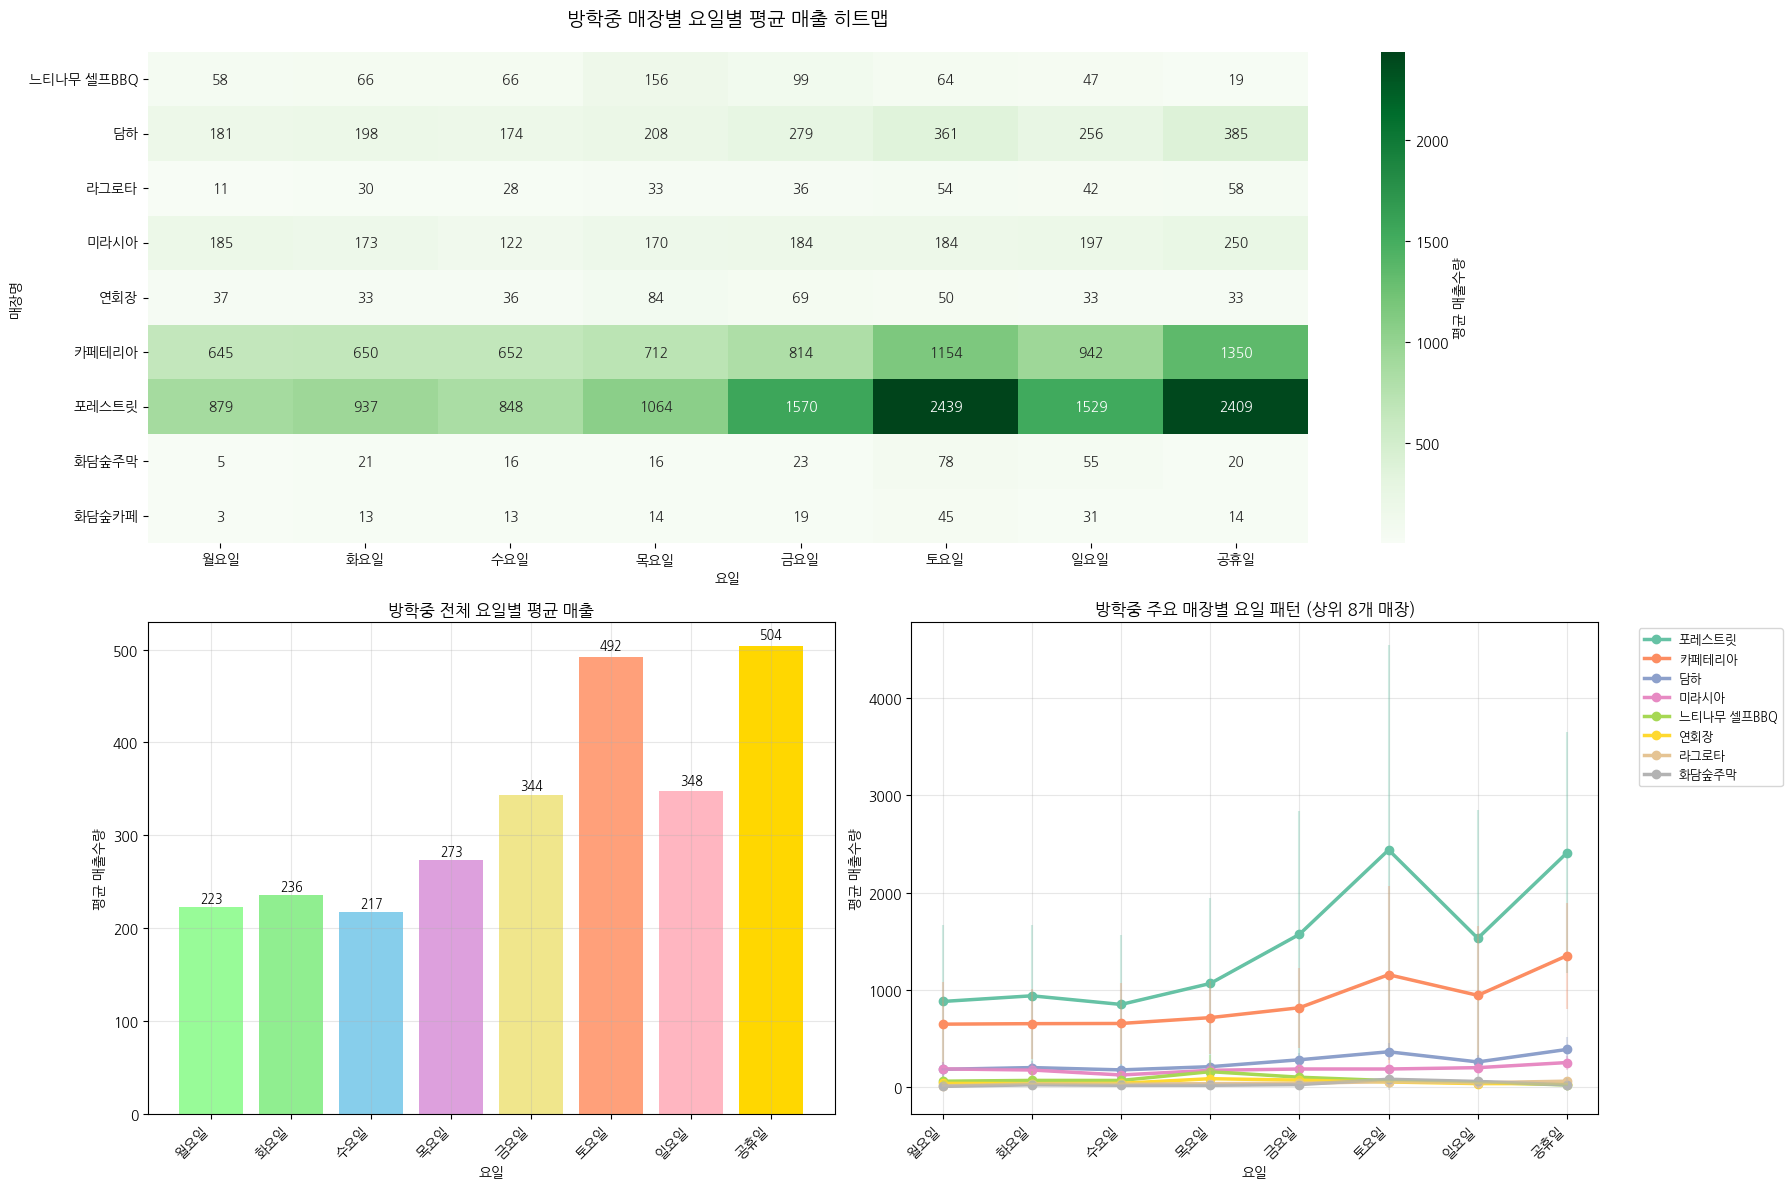


=== 방학중 매장별 패턴 분석 ===

🔍 화담숲주막 방학중 패턴:
  공휴일: 20.4 (데이터 11개)
  금요일: 23.2 (데이터 23개)
  목요일: 16.0 (데이터 26개)
  수요일: 16.1 (데이터 26개)
  월요일: 5.1 (데이터 24개)
  일요일: 55.3 (데이터 23개)
  토요일: 77.9 (데이터 23개)
  화요일: 21.0 (데이터 25개)
  공휴일: 14.3 (데이터 11개)
  금요일: 19.0 (데이터 23개)
  목요일: 13.9 (데이터 26개)
  수요일: 13.1 (데이터 26개)
  월요일: 2.9 (데이터 24개)
  일요일: 30.9 (데이터 23개)
  토요일: 44.8 (데이터 23개)
  화요일: 13.5 (데이터 25개)

=== 방학중 매장별 최적/최악 요일 ===

느티나무 셀프BBQ:
  최고: 목요일 (156.3)
  최저: 공휴일 (19.3)
  편차: 137.0 (711.0% 차이)

담하:
  최고: 공휴일 (385.0)
  최저: 수요일 (174.5)
  편차: 210.5 (120.6% 차이)

라그로타:
  최고: 공휴일 (58.3)
  최저: 월요일 (10.5)
  편차: 47.7 (452.8% 차이)

미라시아:
  최고: 공휴일 (250.0)
  최저: 수요일 (122.2)
  편차: 127.8 (104.7% 차이)

연회장:
  최고: 목요일 (83.7)
  최저: 공휴일 (33.0)
  편차: 50.7 (153.7% 차이)

카페테리아:
  최고: 공휴일 (1350.1)
  최저: 월요일 (645.2)
  편차: 704.9 (109.2% 차이)

포레스트릿:
  최고: 토요일 (2439.0)
  최저: 수요일 (848.1)
  편차: 1590.9 (187.6% 차이)

화담숲주막:
  최고: 토요일 (77.9)
  최저: 월요일 (5.1)
  편차: 72.8 (1432.7% 차이)

화담숲카페:
  최고: 토요일 (44.8)
  최저: 월요일 (2.9)
  편차: 41

In [19]:


# 영업일자를 datetime으로 변환
df['영업일자'] = pd.to_datetime(df['영업일자'])

# 매장명과 메뉴명 분리
df['매장명'] = df['영업장명_메뉴명'].str.split('_').str[0]

# 공휴일 목록 정의
holidays_2023 = [
    '2023-01-01', '2023-01-21', '2023-01-22', '2023-01-23', '2023-01-24',
    '2023-03-01', '2023-05-01', '2023-05-05', '2023-05-27', '2023-05-29',
    '2023-06-06', '2023-08-15', '2023-09-28', '2023-09-29', '2023-09-30',
    '2023-10-02', '2023-10-03', '2023-10-09', '2023-12-25'
]

holidays_2024 = [
    '2024-01-01', '2024-02-09', '2024-02-10', '2024-02-11', '2024-02-12',
    '2024-03-01', '2024-04-10', '2024-05-01', '2024-05-05', '2024-05-06',
    '2024-05-15', '2024-06-06', '2024-08-15', '2024-09-16', '2024-09-17',
    '2024-09-18', '2024-10-01', '2024-10-03', '2024-10-09', '2024-12-25'
]

all_holidays = holidays_2023 + holidays_2024
holiday_dates = pd.to_datetime(all_holidays)

# 요일 정보 추가
df['요일번호'] = df['영업일자'].dt.dayofweek
df['요일명'] = df['영업일자'].dt.day_name()

# 한글 요일명 매핑
weekday_mapping = {
    'Monday': '월요일',
    'Tuesday': '화요일',
    'Wednesday': '수요일',
    'Thursday': '목요일',
    'Friday': '금요일',
    'Saturday': '토요일',
    'Sunday': '일요일'
}
df['요일'] = df['요일명'].map(weekday_mapping)

# 공휴일 여부 확인 및 요일 재분류
df['is_holiday'] = df['영업일자'].isin(holiday_dates)
df['요일_공휴일포함'] = df.apply(lambda row: '공휴일' if row['is_holiday'] else row['요일'], axis=1)

# 학기/방학 시즌 분류
df['month'] = df['영업일자'].dt.month
def classify_season(month):
    if month in [3, 4, 5, 6, 9, 10, 11, 12]:
        return '학기중'
    else:  # 1, 2, 7, 8월
        return '방학중'

df['시즌'] = df['month'].apply(classify_season)

# 방학중 데이터만 필터링
vacation_df = df[df['시즌'] == '방학중'].copy()

print("방학중 데이터 기본 정보:")
print(f"방학중 데이터 수: {len(vacation_df):,}건")
print(f"방학중 분석 기간: {vacation_df['영업일자'].min()} ~ {vacation_df['영업일자'].max()}")
print(f"매장 수: {vacation_df['매장명'].nunique()}개")
print(f"방학중 공휴일 수: {vacation_df['is_holiday'].sum()}건")
print("\n매장 목록:")
for i, store in enumerate(vacation_df['매장명'].unique(), 1):
    print(f"{i:2d}. {store}")

# 요일 순서 정의
weekday_order = ['월요일', '화요일', '수요일', '목요일', '금요일', '토요일', '일요일', '공휴일']

# 방학중 일별 매장별 매출 합계 계산
daily_vacation_sales = vacation_df.groupby(['영업일자', '매장명', '요일_공휴일포함'])['매출수량'].sum().reset_index()

# 방학중 매장별 요일별 평균 매출 계산
store_weekday_vacation = daily_vacation_sales.groupby(['매장명', '요일_공휴일포함'])['매출수량'].agg(['mean', 'std', 'count']).reset_index()
store_weekday_vacation.columns = ['매장명', '요일', '평균매출', '표준편차', '데이터수']
store_weekday_vacation['표준편차'] = store_weekday_vacation['표준편차'].fillna(0)

# 피벗 테이블 생성 (히트맵용)
heatmap_vacation = store_weekday_vacation.pivot(index='매장명', columns='요일', values='평균매출')
heatmap_vacation = heatmap_vacation.reindex(columns=weekday_order)

print(f"\n방학중 매장별 요일별 평균 매출:")
print(heatmap_vacation.round(1))

# 방학중 전체 평균 계산
overall_vacation_avg = daily_vacation_sales.groupby('요일_공휴일포함')['매출수량'].mean()
overall_vacation_avg = overall_vacation_avg.reindex(weekday_order)

print(f"\n방학중 전체 요일별 평균:")
for day, avg in overall_vacation_avg.items():
    if pd.notna(avg):
        print(f"{day}: {avg:.1f}")

# 시각화
fig = plt.figure(figsize=(18, 12))

# 1. 히트맵
ax1 = plt.subplot(2, 2, (1, 2))
mask = heatmap_vacation.isnull()
sns.heatmap(heatmap_vacation, annot=True, fmt='.0f', cmap='Greens',
            mask=mask, ax=ax1, cbar_kws={'label': '평균 매출수량'})
ax1.set_title('방학중 매장별 요일별 평균 매출 히트맵', fontsize=14, pad=20)
ax1.set_xlabel('요일')
ax1.set_ylabel('매장명')

# 2. 전체 평균 바차트
ax2 = plt.subplot(2, 2, 3)
valid_days = overall_vacation_avg.dropna()
colors = ['#98fb98', '#90ee90', '#87ceeb', '#dda0dd', '#f0e68c', '#ffa07a', '#ffb6c1', '#ffd700']
day_colors = colors[:len(valid_days)]

bars = ax2.bar(range(len(valid_days)), valid_days.values, color=day_colors)
ax2.set_title('방학중 전체 요일별 평균 매출', fontsize=12)
ax2.set_xlabel('요일')
ax2.set_ylabel('평균 매출수량')
ax2.set_xticks(range(len(valid_days)))
ax2.set_xticklabels(valid_days.index, rotation=45, ha='right')
ax2.grid(True, alpha=0.3)

# 막대 위에 값 표시
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
             f'{height:.0f}', ha='center', va='bottom', fontsize=9)

# 3. 상위 매장 라인플롯
ax3 = plt.subplot(2, 2, 4)

# 매장별 총 매출로 정렬하여 상위 매장 선택
store_total_sales = daily_vacation_sales.groupby('매장명')['매출수량'].sum().sort_values(ascending=False)
top_stores = store_total_sales.head(8).index

colors = plt.cm.Set2(np.linspace(0, 1, len(top_stores)))

for i, store in enumerate(top_stores):
    store_data = store_weekday_vacation[store_weekday_vacation['매장명'] == store]
    store_data = store_data.set_index('요일').reindex(weekday_order)

    if not store_data['평균매출'].isna().all():
        # NaN 값이 아닌 데이터만 플롯
        valid_data = store_data['평균매출'].dropna()
        valid_indices = [weekday_order.index(day) for day in valid_data.index]

        ax3.plot(valid_indices, valid_data.values,
                marker='o', linewidth=2.5, label=store, color=colors[i], markersize=6)

        # 에러바 추가 (표준편차)
        valid_std = store_data.loc[valid_data.index, '표준편차']
        ax3.errorbar(valid_indices, valid_data.values,
                    yerr=valid_std.values, alpha=0.3, color=colors[i])

ax3.set_title('방학중 주요 매장별 요일 패턴 (상위 8개 매장)', fontsize=12)
ax3.set_xlabel('요일')
ax3.set_ylabel('평균 매출수량')
ax3.set_xticks(range(len(weekday_order)))
ax3.set_xticklabels(weekday_order, rotation=45, ha='right')
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 방학중 상세 분석
print("\n=== 방학중 매장별 패턴 분석 ===")

# 화담숲주막 특별 분석
hwadamsup_data = store_weekday_vacation[store_weekday_vacation['매장명'].str.contains('화담숲', na=False)]
if len(hwadamsup_data) > 0:
    print("\n🔍 화담숲주막 방학중 패턴:")
    for _, row in hwadamsup_data.iterrows():
        print(f"  {row['요일']}: {row['평균매출']:.1f} (데이터 {row['데이터수']}개)")

# 각 매장의 방학중 최고/최저 요일
print(f"\n=== 방학중 매장별 최적/최악 요일 ===")
for store in heatmap_vacation.index:
    store_data = heatmap_vacation.loc[store].dropna()
    if len(store_data) > 0:
        max_day = store_data.idxmax()
        min_day = store_data.idxmin()
        max_val = store_data.max()
        min_val = store_data.min()

        print(f"\n{store}:")
        print(f"  최고: {max_day} ({max_val:.1f})")
        print(f"  최저: {min_day} ({min_val:.1f})")
        print(f"  편차: {max_val - min_val:.1f} ({((max_val/min_val - 1) * 100):.1f}% 차이)")

# 방학중 공휴일 효과
print(f"\n=== 방학중 공휴일 vs 평일 비교 ===")
if '공휴일' in overall_vacation_avg.index and pd.notna(overall_vacation_avg['공휴일']):
    holiday_avg = overall_vacation_avg['공휴일']
    regular_days = ['월요일', '화요일', '수요일', '목요일', '금요일', '토요일', '일요일']
    regular_avg = overall_vacation_avg[regular_days].mean()

    print(f"방학중 공휴일 평균: {holiday_avg:.1f}")
    print(f"방학중 일반 요일 평균: {regular_avg:.1f}")
    print(f"방학중 공휴일 효과: {((holiday_avg/regular_avg - 1) * 100):+.1f}%")

# 방학중 매장별 패턴 유형
print(f"\n=== 방학중 매장별 패턴 유형 ===")
for store in heatmap_vacation.index:
    store_data = heatmap_vacation.loc[store].dropna()
    if len(store_data) >= 3:
        weekend_days = ['토요일', '일요일']
        weekday_days = ['월요일', '화요일', '수요일', '목요일', '금요일']

        weekend_data = store_data[[day for day in weekend_days if day in store_data.index]]
        weekday_data = store_data[[day for day in weekday_days if day in store_data.index]]

        if len(weekend_data) > 0 and len(weekday_data) > 0:
            weekend_avg = weekend_data.mean()
            weekday_avg = weekday_data.mean()
            holiday_avg = store_data.get('공휴일', 0)

            if holiday_avg > max(weekend_avg, weekday_avg) * 1.1:
                pattern = "공휴일형"
            elif weekend_avg > weekday_avg * 1.2:
                pattern = "주말형"
            elif weekday_avg > weekend_avg * 1.2:
                pattern = "평일형"
            else:
                pattern = "균등형"

            print(f"{store}: {pattern}")
            print(f"  평일: {weekday_avg:.1f}, 주말: {weekend_avg:.1f}, 공휴일: {holiday_avg:.1f}")

print("\n=== 방학중 분석 완료 ===")
print("🌴 방학중에는 일반적으로 가족 단위 방문객이 많아 주말/공휴일 효과가 클 것으로 예상됩니다.")
print("📊 히트맵에서 각 매장의 방학중 요일별 선호도를 확인할 수 있습니다.")
print("📈 화담숲주막의 방학중 패턴이 다른 매장들과 어떻게 다른지 주목해보세요!")

# 화담숲 주말 공휴일

In [34]:
csv_path = '/content/drive/MyDrive/data/train/train.csv'

df = pd.read_csv(csv_path)
df.head()

,영업일자,영업장명_메뉴명,매출수량
0,2023.1.1,느티나무 셀프BBQ_1인 수저세트,0
1,2023.1.2,느티나무 셀프BBQ_1인 수저세트,0
2,2023.1.3,느티나무 셀프BBQ_1인 수저세트,0
3,2023.1.4,느티나무 셀프BBQ_1인 수저세트,0
4,2023.1.5,느티나무 셀프BBQ_1인 수저세트,0


In [36]:
df.head()

,영업일자,영업장명_메뉴명,매출수량
0,2023.1.1,느티나무 셀프BBQ_1인 수저세트,0
1,2023.1.2,느티나무 셀프BBQ_1인 수저세트,0
2,2023.1.3,느티나무 셀프BBQ_1인 수저세트,0
3,2023.1.4,느티나무 셀프BBQ_1인 수저세트,0
4,2023.1.5,느티나무 셀프BBQ_1인 수저세트,0


In [37]:
df.shape

(102676, 3)

## 화담숲주막, 느티나무 셀프 BBQ 4월

화담숲주막이 포함된 데이터:
총 4256개 행 추출

추출된 데이터 샘플:
           영업일자        영업장명_메뉴명  매출수량
95760  2023.1.1  화담숲주막_느린마을 막걸리     0
95761  2023.1.2  화담숲주막_느린마을 막걸리     0
95762  2023.1.3  화담숲주막_느린마을 막걸리     0
95763  2023.1.4  화담숲주막_느린마을 막걸리     0
95764  2023.1.5  화담숲주막_느린마을 막걸리     0

2023년 1월 화담숲주막 데이터: 240개 행

화담숲주막 메뉴 종류: ['느린마을 막걸리', '단호박 식혜 ', '병천순대', '스프라이트', '참살이 막걸리', '찹쌀식혜', '콜라', '해물파전']


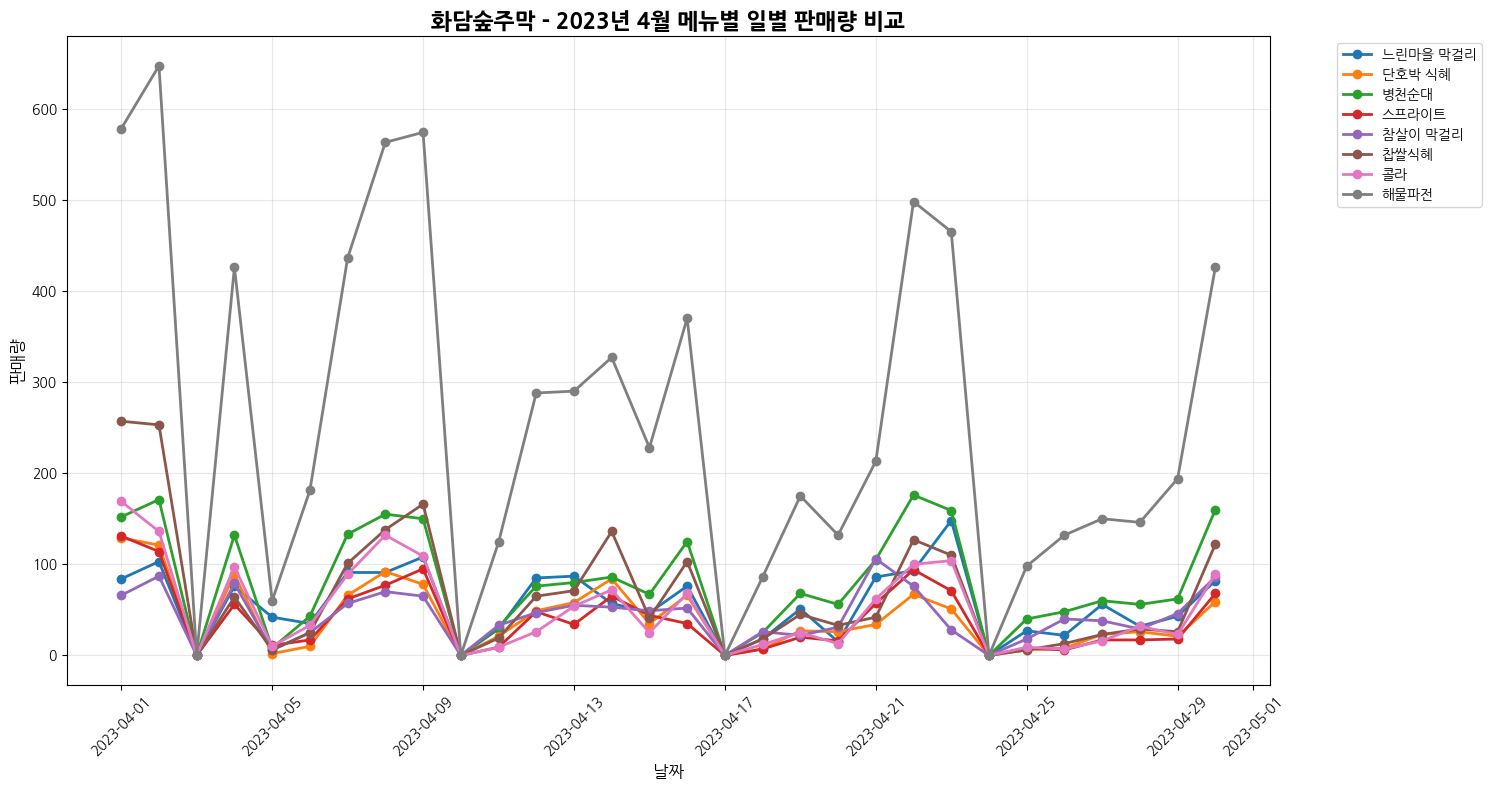

In [43]:
month = 4

# 1. '화담숲주막'이 포함된 행 추출
화담숲주막_데이터 = df[df['영업장명_메뉴명'].str.contains('화담숲주막', na=False)]

print("화담숲주막이 포함된 데이터:")
print(f"총 {len(화담숲주막_데이터)}개 행 추출")
print("\n추출된 데이터 샘플:")
print(화담숲주막_데이터.head())

# 2. 2023년 1월 데이터만 필터링
# 영업일자를 datetime 형식으로 변환 (점으로 구분된 날짜 형식 처리)
화담숲주막_데이터 = 화담숲주막_데이터.copy()
화담숲주막_데이터['영업일자'] = pd.to_datetime(화담숲주막_데이터['영업일자'], format='%Y.%m.%d')

# 2023년 1월 데이터 필터링
jan_2023_data = 화담숲주막_데이터[
    (화담숲주막_데이터['영업일자'].dt.year == 2023) &
    (화담숲주막_데이터['영업일자'].dt.month == month)
]

print(f"\n2023년 1월 화담숲주막 데이터: {len(jan_2023_data)}개 행")

# 3. 메뉴별로 분리
# 영업장명_메뉴명에서 메뉴명만 추출 (언더스코어 뒤의 부분)
jan_2023_data = jan_2023_data.copy()
jan_2023_data['메뉴명'] = jan_2023_data['영업장명_메뉴명'].str.split('_').str[1]

# 메뉴별 고유값 확인
unique_menus = jan_2023_data['메뉴명'].unique()
print(f"\n화담숲주막 메뉴 종류: {list(unique_menus)}")

# 4. 일별 메뉴별 판매량 집계
daily_menu_sales = jan_2023_data.groupby(['영업일자', '메뉴명'])['매출수량'].sum().reset_index()

# 5. 시각화 - 메뉴별로 개별 그래프 생성
num_menus = len(unique_menus)
# fig, axes = plt.subplots(nrows=num_menus, ncols=1, figsize=(15, num_menus * 3))

# axes를 항상 배열로 만들기
# if num_menus == 1:
#     axes = [axes]

# 메뉴별로 개별 그래프 생성
# for i, menu in enumerate(unique_menus):
#     menu_data = daily_menu_sales[daily_menu_sales['메뉴명'] == menu]
#     ax = axes[i]

#     # 선 그래프와 점 그래프를 함께 표시
#     ax.plot(menu_data['영업일자'], menu_data['매출수량'],
#             marker='o', linewidth=2, markersize=6, label=menu)

#     ax.set_title(f'{menu} - 2023년 1월 일별 판매량', fontsize=14, fontweight='bold')
#     ax.set_xlabel('날짜', fontsize=12)
#     ax.set_ylabel('판매량', fontsize=12)
#     ax.grid(True, alpha=0.3)

#     # x축 날짜 포맷 설정
#     ax.tick_params(axis='x', rotation=45)

#     # 판매량 값을 점 위에 표시
#     for x, y in zip(menu_data['영업일자'], menu_data['매출수량']):
#         ax.annotate(f'{int(y)}', (x, y), textcoords="offset points",
#                    xytext=(0,10), ha='center', fontsize=9)

# plt.tight_layout()
# plt.show()

# 6. 전체 메뉴를 하나의 그래프에 표시
plt.figure(figsize=(15, 8))

for menu in unique_menus:
    menu_data = daily_menu_sales[daily_menu_sales['메뉴명'] == menu]
    plt.plot(menu_data['영업일자'], menu_data['매출수량'],
             marker='o', linewidth=2, markersize=6, label=menu)

plt.title(f'화담숲주막 - 2023년 {month}월 메뉴별 일별 판매량 비교', fontsize=16, fontweight='bold')
plt.xlabel('날짜', fontsize=12)
plt.ylabel('판매량', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 7. 요약 통계
# print("\n=== 화담숲주막 2023년 1월 판매량 요약 ===")
# summary_stats = jan_2023_data.groupby('메뉴명')['매출수량'].agg([
#     'count', 'sum', 'mean', 'std', 'min', 'max'
# ]).round(2)

# print(summary_stats)

# # 8. 일별 총 판매량
# daily_total = jan_2023_data.groupby('영업일자')['매출수량'].sum().reset_index()
# print(f"\n일별 총 판매량:")
# for _, row in daily_total.iterrows():
#     print(f"{row['영업일자'].strftime('%Y-%m-%d')}: {int(row['매출수량'])}개")

# # 9. 히트맵으로 표시 (메뉴 x 날짜)
# if len(unique_menus) > 1:
#     pivot_data = daily_menu_sales.pivot(index='메뉴명', columns='영업일자', values='매출수량')
#     pivot_data = pivot_data.fillna(0)

#     plt.figure(figsize=(15, 6))
#     sns.heatmap(pivot_data, annot=True, fmt='g', cmap='YlOrRd',
#                 cbar_kws={'label': '판매량'})
#     plt.title('화담숲주막 - 2023년 1월 메뉴별 일별 판매량 히트맵', fontsize=14, fontweight='bold')
#     plt.xlabel('날짜', fontsize=12)
#     plt.ylabel('메뉴명', fontsize=12)
#     plt.xticks(rotation=45)
#     plt.tight_layout()
#     plt.show()

화담숲주막이 포함된 데이터:
총 4256개 행 추출

추출된 데이터 샘플:
           영업일자        영업장명_메뉴명  매출수량
95760  2023.1.1  화담숲주막_느린마을 막걸리     0
95761  2023.1.2  화담숲주막_느린마을 막걸리     0
95762  2023.1.3  화담숲주막_느린마을 막걸리     0
95763  2023.1.4  화담숲주막_느린마을 막걸리     0
95764  2023.1.5  화담숲주막_느린마을 막걸리     0

2023년 1월 화담숲주막 데이터: 248개 행

화담숲주막 메뉴 종류: ['느린마을 막걸리', '단호박 식혜 ', '병천순대', '스프라이트', '참살이 막걸리', '찹쌀식혜', '콜라', '해물파전']


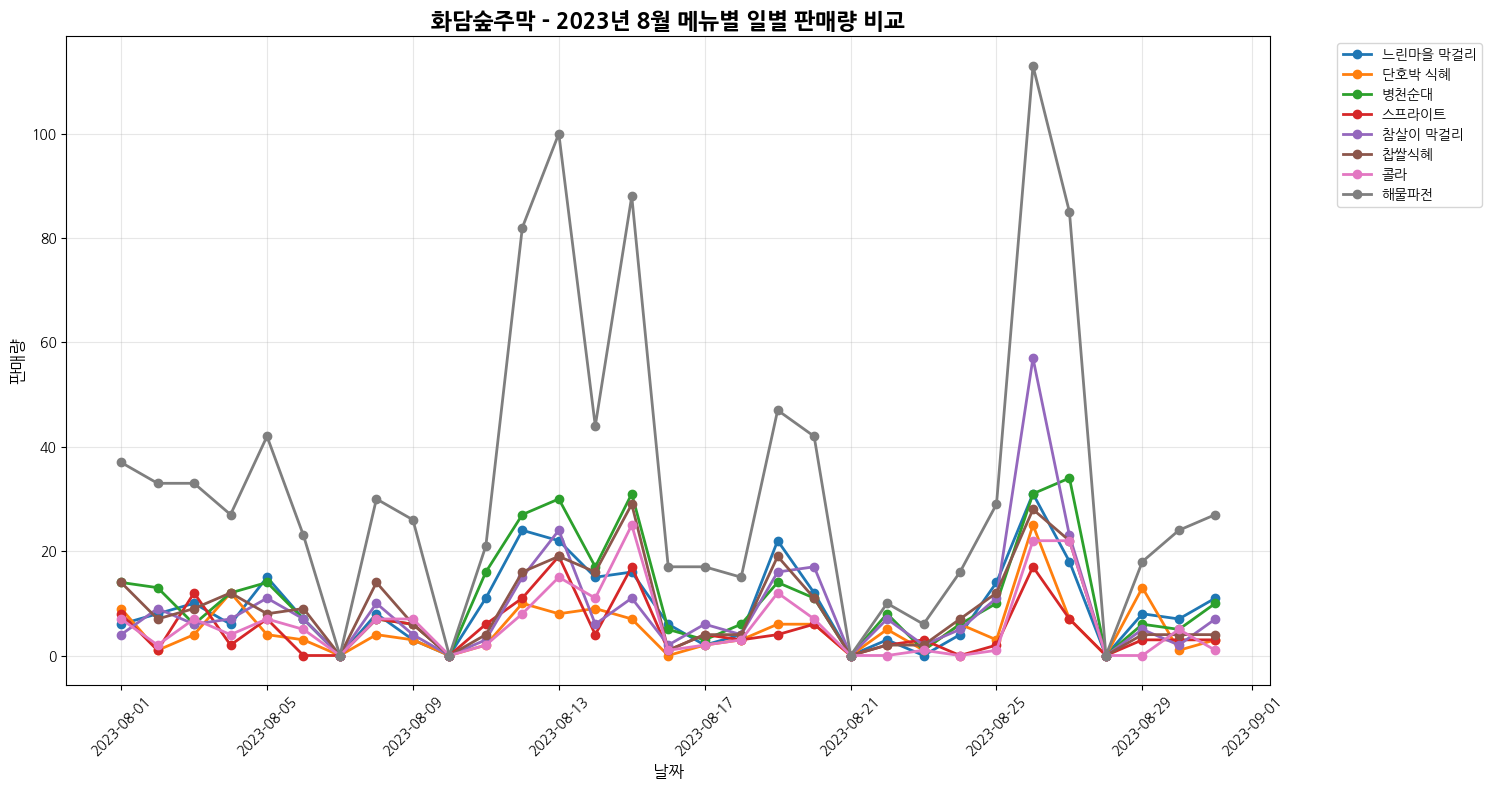

In [46]:
month = 8
restaurant = '화담숲주막'

# 1. '화담숲주막'이 포함된 행 추출
화담숲주막_데이터 = df[df['영업장명_메뉴명'].str.contains(restaurant, na=False)]

print("화담숲주막이 포함된 데이터:")
print(f"총 {len(화담숲주막_데이터)}개 행 추출")
print("\n추출된 데이터 샘플:")
print(화담숲주막_데이터.head())

# 2. 2023년 1월 데이터만 필터링
# 영업일자를 datetime 형식으로 변환 (점으로 구분된 날짜 형식 처리)
화담숲주막_데이터 = 화담숲주막_데이터.copy()
화담숲주막_데이터['영업일자'] = pd.to_datetime(화담숲주막_데이터['영업일자'], format='%Y.%m.%d')

# 2023년 1월 데이터 필터링
jan_2023_data = 화담숲주막_데이터[
    (화담숲주막_데이터['영업일자'].dt.year == 2023) &
    (화담숲주막_데이터['영업일자'].dt.month == month)
]

print(f"\n2023년 1월 화담숲주막 데이터: {len(jan_2023_data)}개 행")

# 3. 메뉴별로 분리
# 영업장명_메뉴명에서 메뉴명만 추출 (언더스코어 뒤의 부분)
jan_2023_data = jan_2023_data.copy()
jan_2023_data['메뉴명'] = jan_2023_data['영업장명_메뉴명'].str.split('_').str[1]

# 메뉴별 고유값 확인
unique_menus = jan_2023_data['메뉴명'].unique()
print(f"\n화담숲주막 메뉴 종류: {list(unique_menus)}")

# 4. 일별 메뉴별 판매량 집계
daily_menu_sales = jan_2023_data.groupby(['영업일자', '메뉴명'])['매출수량'].sum().reset_index()

# 5. 시각화 - 메뉴별로 개별 그래프 생성
num_menus = len(unique_menus)

# 6. 전체 메뉴를 하나의 그래프에 표시
plt.figure(figsize=(15, 8))

for menu in unique_menus:
    menu_data = daily_menu_sales[daily_menu_sales['메뉴명'] == menu]
    plt.plot(menu_data['영업일자'], menu_data['매출수량'],
             marker='o', linewidth=2, markersize=6, label=menu)

plt.title(f'{restaurant} - 2023년 {month}월 메뉴별 일별 판매량 비교', fontsize=16, fontweight='bold')
plt.xlabel('날짜', fontsize=12)
plt.ylabel('판매량', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 느티나무 셀프 BBQ 4월

화담숲주막이 포함된 데이터:
총 12236개 행 추출

추출된 데이터 샘플:
       영업일자            영업장명_메뉴명  매출수량
0  2023.1.1  느티나무 셀프BBQ_1인 수저세트     0
1  2023.1.2  느티나무 셀프BBQ_1인 수저세트     0
2  2023.1.3  느티나무 셀프BBQ_1인 수저세트     0
3  2023.1.4  느티나무 셀프BBQ_1인 수저세트     0
4  2023.1.5  느티나무 셀프BBQ_1인 수저세트     0

2023년 1월 화담숲주막 데이터: 690개 행

화담숲주막 메뉴 종류: ['1인 수저세트', 'BBQ55(단체)', '대여료 30,000원', '대여료 60,000원', '대여료 90,000원', '본삼겹 (단품,실내)', '스프라이트 (단체)', '신라면', '쌈야채세트', '쌈장', '육개장 사발면', '일회용 소주컵', '일회용 종이컵', '잔디그늘집 대여료 (12인석)', '잔디그늘집 대여료 (6인석)', '잔디그늘집 의자 추가', '참이슬 (단체)', '친환경 접시 14cm', '친환경 접시 23cm', '카스 병(단체)', '콜라 (단체)', '햇반', '허브솔트']


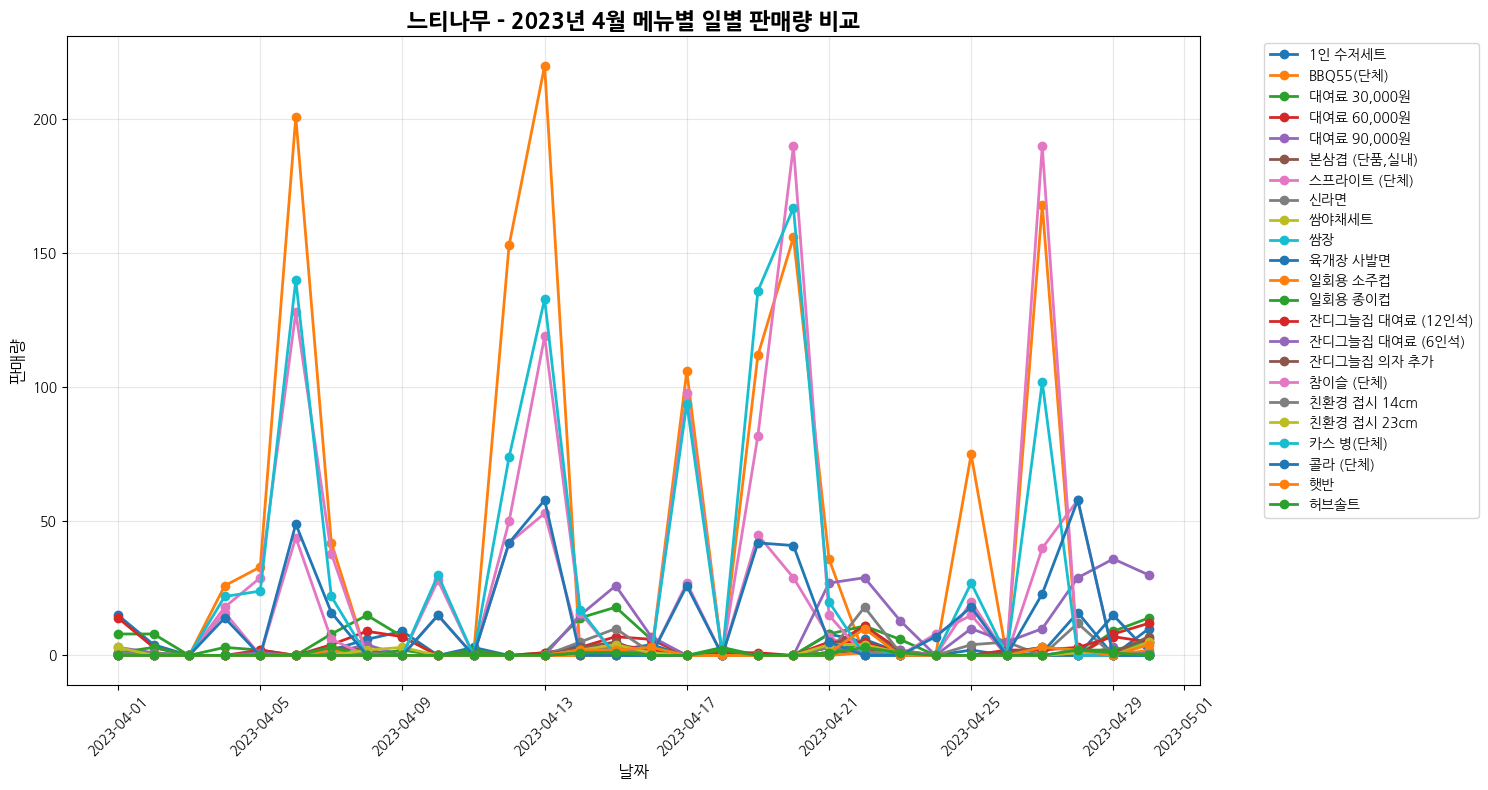

In [45]:
month = 4
restaurant = '느티나무'

# 1. '화담숲주막'이 포함된 행 추출
화담숲주막_데이터 = df[df['영업장명_메뉴명'].str.contains(restaurant, na=False)]

print("화담숲주막이 포함된 데이터:")
print(f"총 {len(화담숲주막_데이터)}개 행 추출")
print("\n추출된 데이터 샘플:")
print(화담숲주막_데이터.head())

# 2. 2023년 1월 데이터만 필터링
# 영업일자를 datetime 형식으로 변환 (점으로 구분된 날짜 형식 처리)
화담숲주막_데이터 = 화담숲주막_데이터.copy()
화담숲주막_데이터['영업일자'] = pd.to_datetime(화담숲주막_데이터['영업일자'], format='%Y.%m.%d')

# 2023년 1월 데이터 필터링
jan_2023_data = 화담숲주막_데이터[
    (화담숲주막_데이터['영업일자'].dt.year == 2023) &
    (화담숲주막_데이터['영업일자'].dt.month == month)
]

print(f"\n2023년 1월 화담숲주막 데이터: {len(jan_2023_data)}개 행")

# 3. 메뉴별로 분리
# 영업장명_메뉴명에서 메뉴명만 추출 (언더스코어 뒤의 부분)
jan_2023_data = jan_2023_data.copy()
jan_2023_data['메뉴명'] = jan_2023_data['영업장명_메뉴명'].str.split('_').str[1]

# 메뉴별 고유값 확인
unique_menus = jan_2023_data['메뉴명'].unique()
print(f"\n화담숲주막 메뉴 종류: {list(unique_menus)}")

# 4. 일별 메뉴별 판매량 집계
daily_menu_sales = jan_2023_data.groupby(['영업일자', '메뉴명'])['매출수량'].sum().reset_index()

# 5. 시각화 - 메뉴별로 개별 그래프 생성
num_menus = len(unique_menus)

# 6. 전체 메뉴를 하나의 그래프에 표시
plt.figure(figsize=(15, 8))

for menu in unique_menus:
    menu_data = daily_menu_sales[daily_menu_sales['메뉴명'] == menu]
    plt.plot(menu_data['영업일자'], menu_data['매출수량'],
             marker='o', linewidth=2, markersize=6, label=menu)

plt.title(f'{restaurant} - 2023년 {month}월 메뉴별 일별 판매량 비교', fontsize=16, fontweight='bold')
plt.xlabel('날짜', fontsize=12)
plt.ylabel('판매량', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 느티나무 셀프 BBQ 8월

화담숲주막이 포함된 데이터:
총 12236개 행 추출

추출된 데이터 샘플:
       영업일자            영업장명_메뉴명  매출수량
0  2023.1.1  느티나무 셀프BBQ_1인 수저세트     0
1  2023.1.2  느티나무 셀프BBQ_1인 수저세트     0
2  2023.1.3  느티나무 셀프BBQ_1인 수저세트     0
3  2023.1.4  느티나무 셀프BBQ_1인 수저세트     0
4  2023.1.5  느티나무 셀프BBQ_1인 수저세트     0

2023년 1월 화담숲주막 데이터: 713개 행

화담숲주막 메뉴 종류: ['1인 수저세트', 'BBQ55(단체)', '대여료 30,000원', '대여료 60,000원', '대여료 90,000원', '본삼겹 (단품,실내)', '스프라이트 (단체)', '신라면', '쌈야채세트', '쌈장', '육개장 사발면', '일회용 소주컵', '일회용 종이컵', '잔디그늘집 대여료 (12인석)', '잔디그늘집 대여료 (6인석)', '잔디그늘집 의자 추가', '참이슬 (단체)', '친환경 접시 14cm', '친환경 접시 23cm', '카스 병(단체)', '콜라 (단체)', '햇반', '허브솔트']


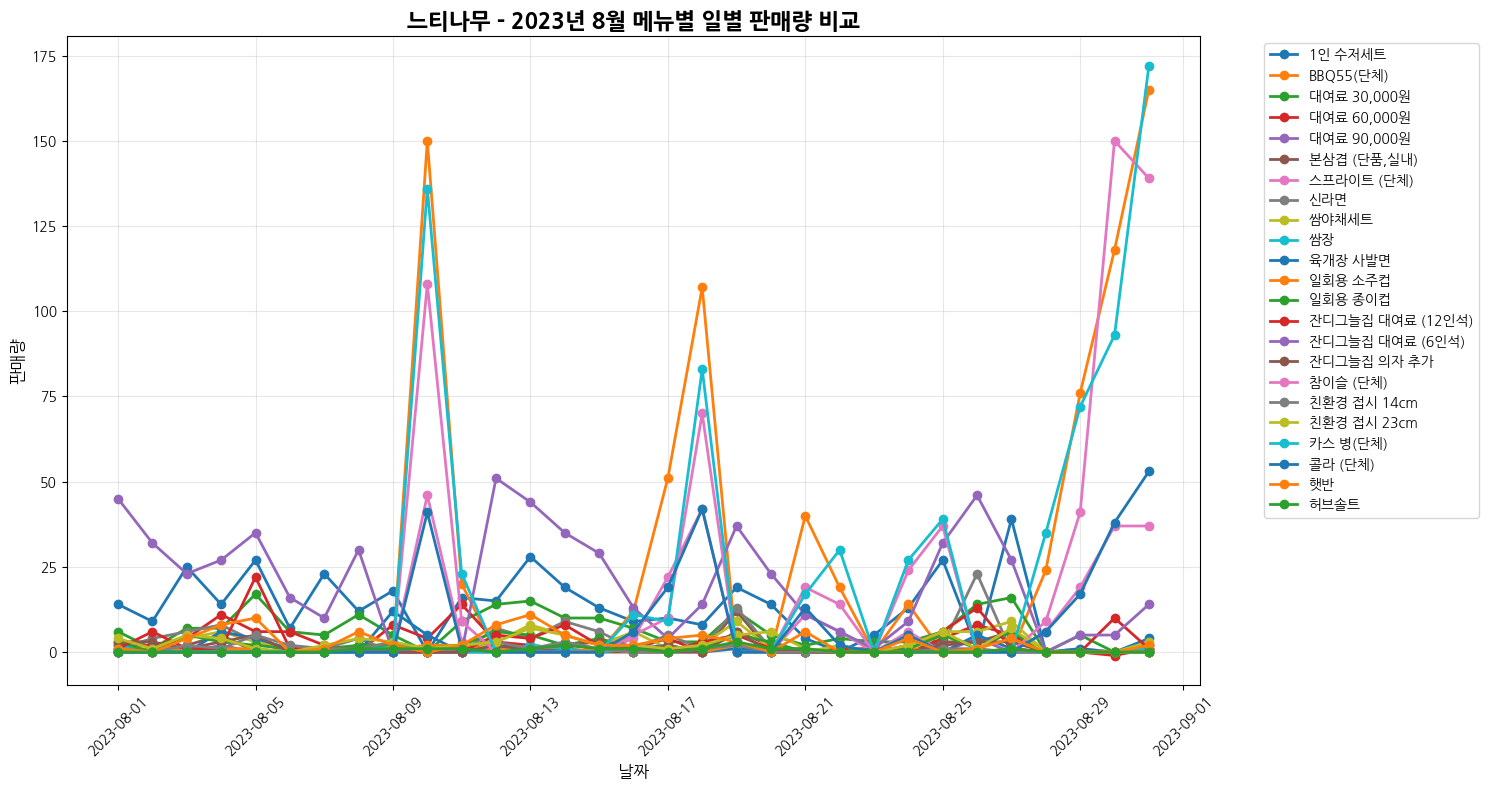

In [47]:
month = 8
restaurant = '느티나무'

# 1. '화담숲주막'이 포함된 행 추출
화담숲주막_데이터 = df[df['영업장명_메뉴명'].str.contains(restaurant, na=False)]

print("화담숲주막이 포함된 데이터:")
print(f"총 {len(화담숲주막_데이터)}개 행 추출")
print("\n추출된 데이터 샘플:")
print(화담숲주막_데이터.head())

# 2. 2023년 1월 데이터만 필터링
# 영업일자를 datetime 형식으로 변환 (점으로 구분된 날짜 형식 처리)
화담숲주막_데이터 = 화담숲주막_데이터.copy()
화담숲주막_데이터['영업일자'] = pd.to_datetime(화담숲주막_데이터['영업일자'], format='%Y.%m.%d')

# 2023년 1월 데이터 필터링
jan_2023_data = 화담숲주막_데이터[
    (화담숲주막_데이터['영업일자'].dt.year == 2023) &
    (화담숲주막_데이터['영업일자'].dt.month == month)
]

print(f"\n2023년 1월 화담숲주막 데이터: {len(jan_2023_data)}개 행")

# 3. 메뉴별로 분리
# 영업장명_메뉴명에서 메뉴명만 추출 (언더스코어 뒤의 부분)
jan_2023_data = jan_2023_data.copy()
jan_2023_data['메뉴명'] = jan_2023_data['영업장명_메뉴명'].str.split('_').str[1]

# 메뉴별 고유값 확인
unique_menus = jan_2023_data['메뉴명'].unique()
print(f"\n화담숲주막 메뉴 종류: {list(unique_menus)}")

# 4. 일별 메뉴별 판매량 집계
daily_menu_sales = jan_2023_data.groupby(['영업일자', '메뉴명'])['매출수량'].sum().reset_index()

# 5. 시각화 - 메뉴별로 개별 그래프 생성
num_menus = len(unique_menus)

# 6. 전체 메뉴를 하나의 그래프에 표시
plt.figure(figsize=(15, 8))

for menu in unique_menus:
    menu_data = daily_menu_sales[daily_menu_sales['메뉴명'] == menu]
    plt.plot(menu_data['영업일자'], menu_data['매출수량'],
             marker='o', linewidth=2, markersize=6, label=menu)

plt.title(f'{restaurant} - 2023년 {month}월 메뉴별 일별 판매량 비교', fontsize=16, fontweight='bold')
plt.xlabel('날짜', fontsize=12)
plt.ylabel('판매량', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()